# Machine learning- based prediction of Coronary Artery Disease(CAD)
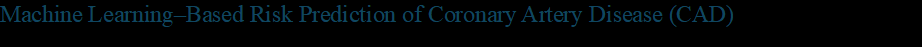

## Data Provisioning


In [1]:
import pandas as pd
import numpy as np

# assigning column names

cols = ["age","sex","cp","trestbps","chol","fbs","restecg",
        "thalach","exang","oldpeak","slope","ca","thal","target"]

cleveland_df = pd.read_csv("data/processed.cleveland.data", header=None, names=cols, na_values=["?", -9.0])

# ensuring all columns are numbers
for c in cols:
    cleveland_df[c] = pd.to_numeric(cleveland_df[c], errors="coerce")

# Map categorical codes to 0-based
cleveland_df['cp']    = cleveland_df['cp'].map({1:0, 2:1, 3:2, 4:3})
cleveland_df['restecg'] = cleveland_df['restecg'].map({0:0, 1:1, 2:2})
cleveland_df['slope'] = cleveland_df['slope'].map({1:0, 2:1, 3:2})
cleveland_df['thal']  = cleveland_df['thal'].map({3:0, 6:1, 7:2})

# giving target binary values
cleveland_df['target'] = (cleveland_df['target'] > 0).astype(int)


# quick sanity checks
print("Unique cp:", cleveland_df['cp'].unique())
print("Unique slope:", cleveland_df['slope'].unique())
print("Unique thal:", cleveland_df['thal'].unique())


print(cleveland_df.shape)
print(cleveland_df.info())
display(cleveland_df.head())


Unique cp: [0 3 2 1]
Unique slope: [2 1 0]
Unique thal: [ 1.  0.  2. nan]
(303, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int32  
dtypes: float64(10), int32(1), int64(3)
memory usage: 32.1 KB
None


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,0,145.0,233.0,1.0,2,150.0,0.0,2.3,2,0.0,1.0,0
1,67.0,1.0,3,160.0,286.0,0.0,2,108.0,1.0,1.5,1,3.0,0.0,1
2,67.0,1.0,3,120.0,229.0,0.0,2,129.0,1.0,2.6,1,2.0,2.0,1
3,37.0,1.0,2,130.0,250.0,0.0,0,187.0,0.0,3.5,2,0.0,0.0,0
4,41.0,0.0,1,130.0,204.0,0.0,2,172.0,0.0,1.4,0,0.0,0.0,0


In [2]:
ranges = cleveland_df.apply(pd.to_numeric, errors="coerce").agg(["min","max"]).T
print(ranges)

            min    max
age        29.0   77.0
sex         0.0    1.0
cp          0.0    3.0
trestbps   94.0  200.0
chol      126.0  564.0
fbs         0.0    1.0
restecg     0.0    2.0
thalach    71.0  202.0
exang       0.0    1.0
oldpeak     0.0    6.2
slope       0.0    2.0
ca          0.0    3.0
thal        0.0    2.0
target      0.0    1.0


## Handling missing values


In [3]:
print(cleveland_df.isna().sum())


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [4]:
cleveland_df["ca"] = cleveland_df["ca"].fillna(cleveland_df["ca"].mode()[0])
cleveland_df["thal"] = cleveland_df["thal"].fillna(cleveland_df["thal"].mode()[0])
print(cleveland_df.isna().sum())


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


I used the mode instead of the mean for the feature thal because it is categorical and the mode is the most appropriate measure for categorical data. Although ca is a numerical feature, it takes on discrete values rather than continuous ones, so using the mode is also more meaningful for summarizing its most common value.

## Count of positive and negative samples

In [5]:
cleveland_df.target.value_counts()

target
0    164
1    139
Name: count, dtype: int64

### Distribution of CAD visualised

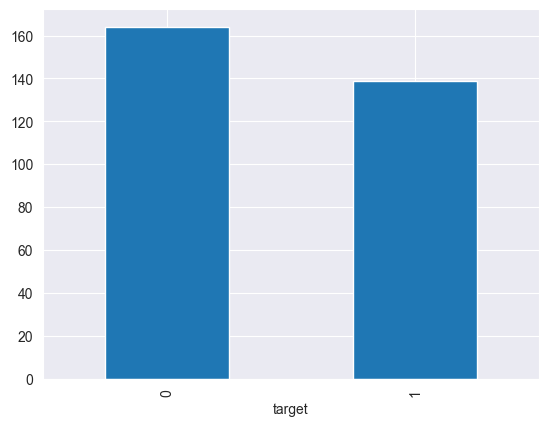

In [6]:
cleveland_df.target.value_counts().plot(kind="bar");

The conclusion is the amount of patients who have and do not have coronary artery disease is fairly even so the dataset is balanced. This is important because a balanced dataset reduces the risk of bias in model training and ensures more reliable performance evaluation.

## Boxplots for numerical values

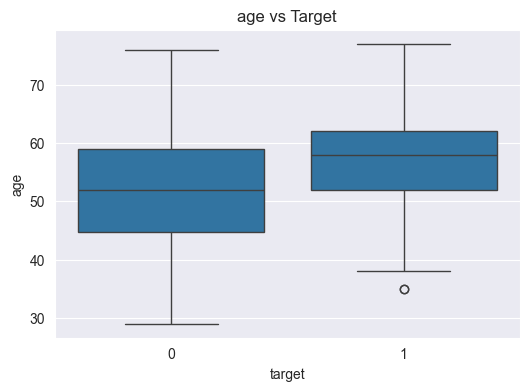

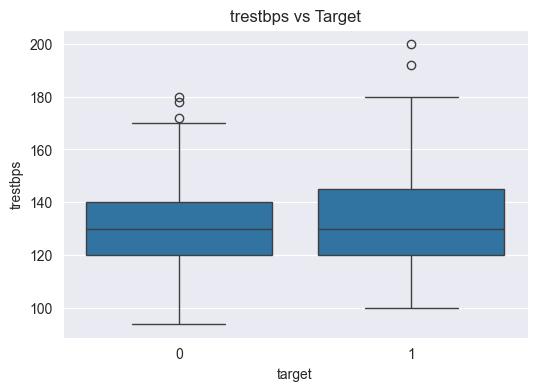

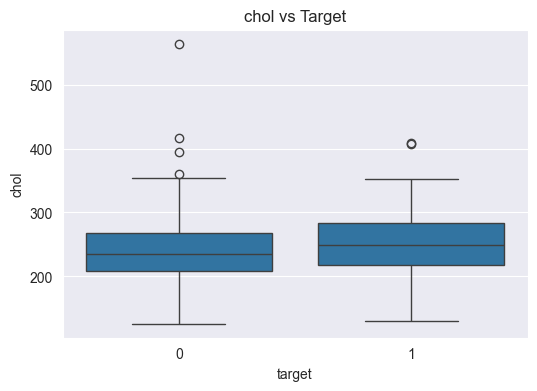

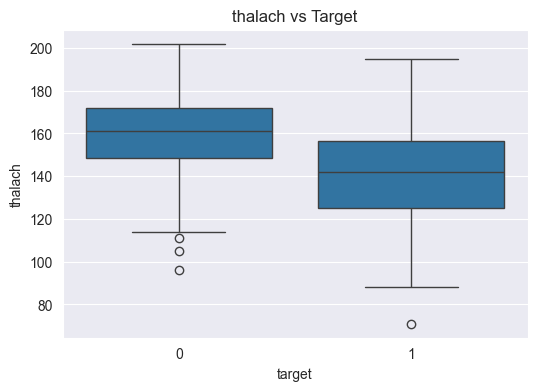

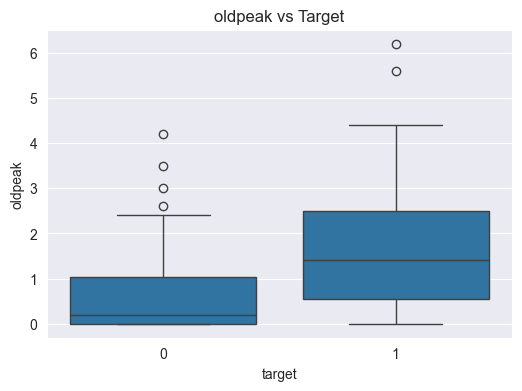

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for feature in numeric_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='target', y=feature, data=cleveland_df)
    plt.title(f'{feature} vs Target')
    plt.show()


The boxplots compare numeric variables to the target variable. The median differences between **age**, **thalach** and **oldpeak** and the target show that these features are the most important numeric predictors. In conclusion, older patient have higher risk of having CAD. Patients who achieve a lower max heart rate during exercise are more likely to have the disease. A higher oldpeak reflects abnormal heart response during exercise which is a strong sign of CAD. These three features show strong class separation. They are likely to be highly predictive in the machine learning model.

## Bar charts for categorical features and numerical (discrete)

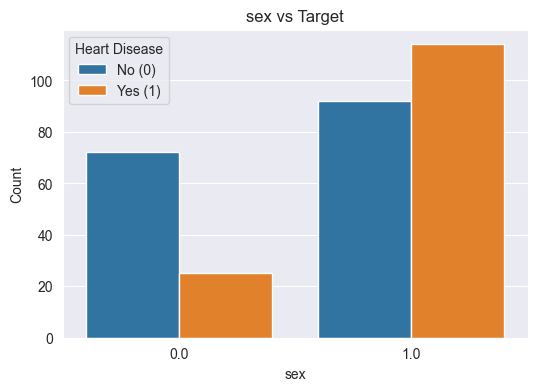

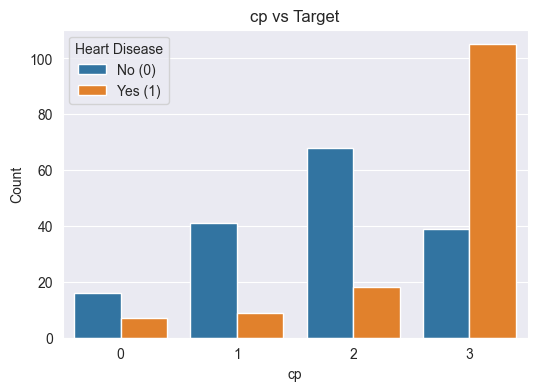

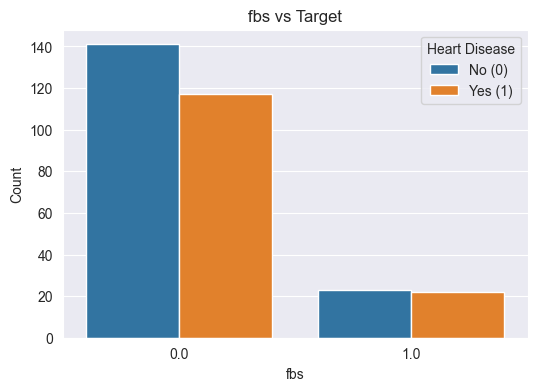

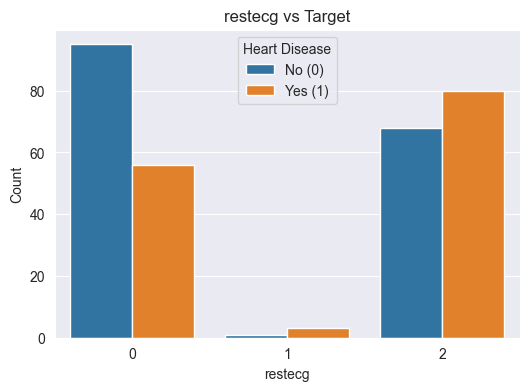

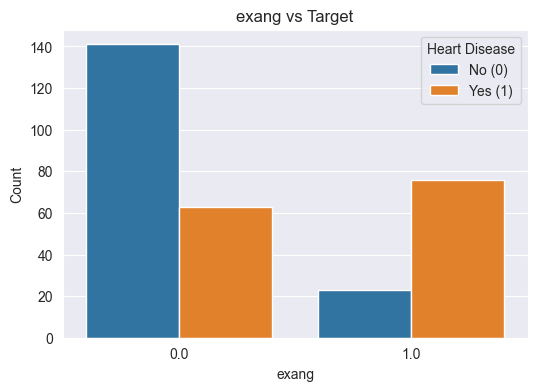

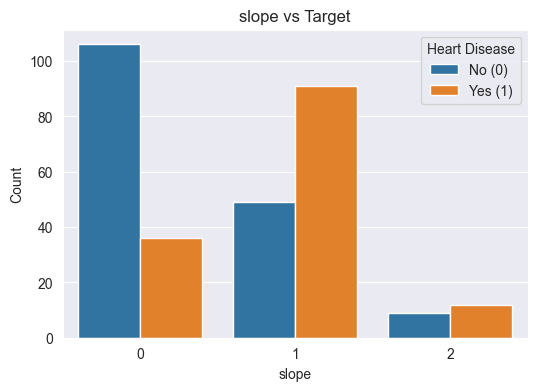

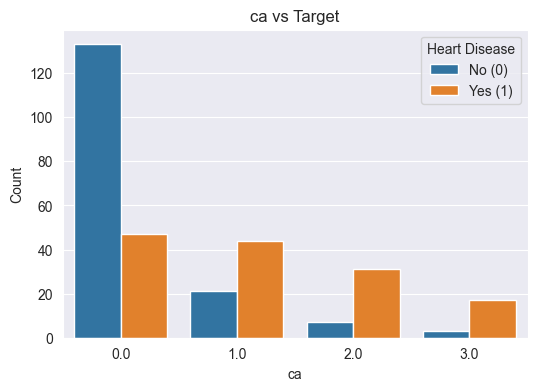

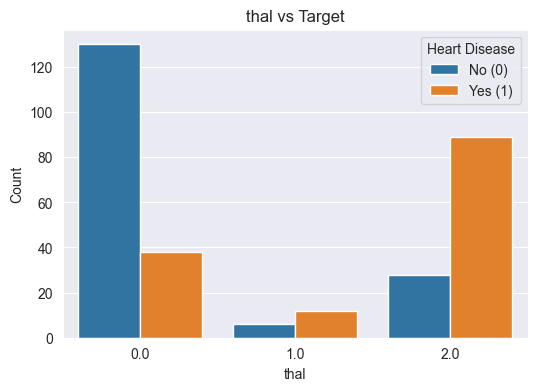

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

for feature in categorical_features:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=cleveland_df, x=feature, hue='target')
    plt.title(f'{feature} vs Target')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.legend(title='Heart Disease', labels=['No (0)', 'Yes (1)'])
    plt.show()


Chest pain is one of the most important predictors with type 3 being strongly associated with heart disease. Sex is also important because men are more likely to have CAD than women. The slope is another key indicator because patients with a flat slope (value 1) are more likely to have heart disease, while those with an upsloping slope (value 0) are less likely. The number of major vessels (ca) also shows a clear pattern: having zero visible vessels is linked to low risk, while having one or more vessels is associated with a higher risk. Similarly, the thalassemia result (thal) is very predictive: a normal result (0) indicates lower risk, whereas fixed (1) or reversible defects (2) are linked to a much higher risk of heart disease.

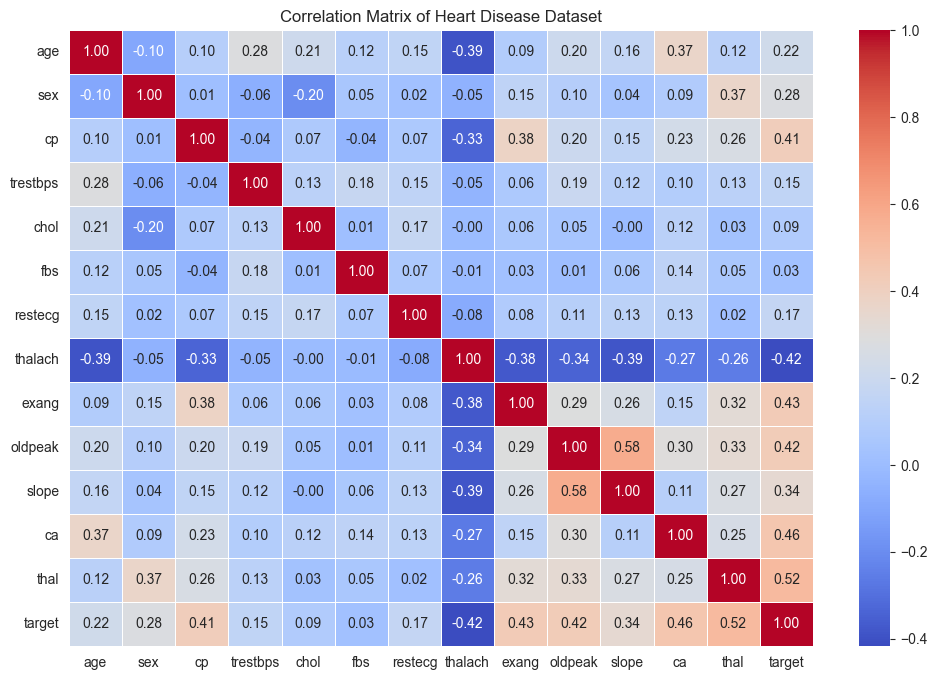

In [9]:
corr = cleveland_df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Heart Disease Dataset")
plt.show()


The correlation matrix confirms that the most important features for predicting CAD are thal, ca, cp, oldpeak, exang, thalach. These features have the strongest positive or negative relationship with the target variable. Slope, sex and age have moderate predictive power, while chol, fbs, restecg and trestbps show weak correlations.

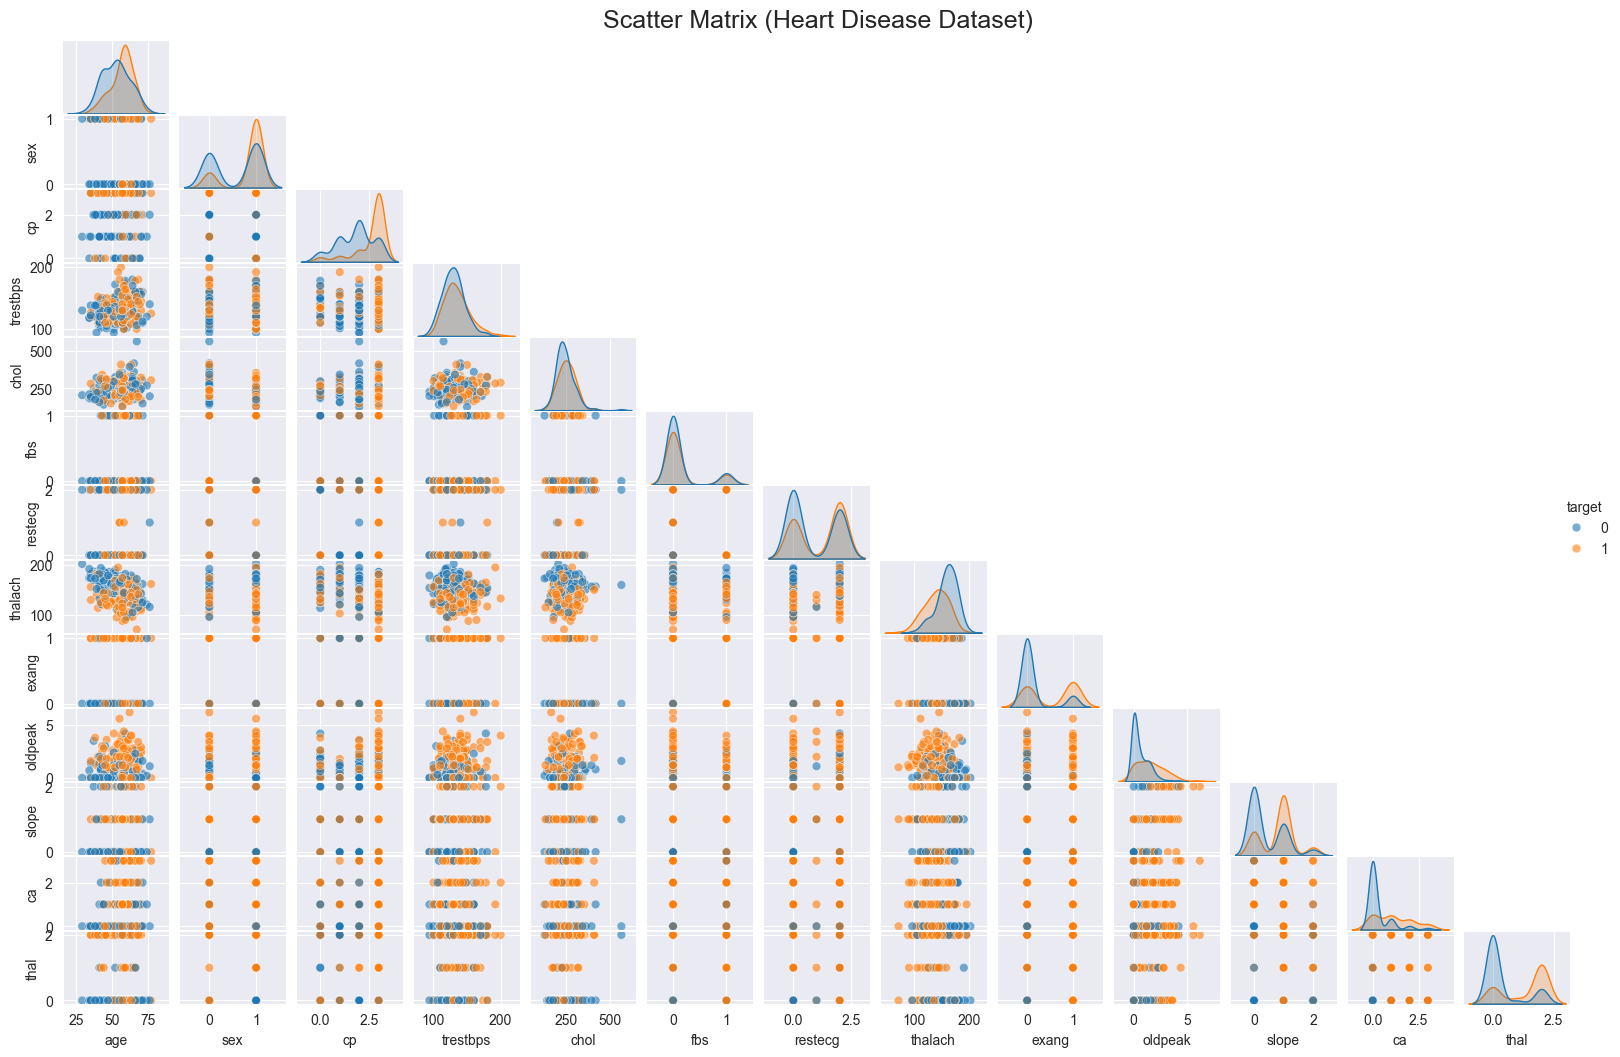

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(
    cleveland_df,
    hue='target',
    diag_kind='kde',
    corner=True,
    plot_kws={'s': 40, 'alpha': 0.6}
)

plt.gcf().set_size_inches(16, 10)
plt.suptitle("Scatter Matrix (Heart Disease Dataset)", fontsize=18, y=1.02)
plt.show()


The conclsuion here is that lower thalach (max heart rate), higher oldpeak (ST depression), higher ca (number of major vessels) is a sign of CAD. Value 1 for exang (exercise-induced angina) show how correlation with having CAD. Age and thalach show strong negative relationship - older patients have lower max heart rate.

## Feature selection


In [11]:
features = ["age", "thalach", "oldpeak", "exang", "sex", "cp", "slope", "ca", "thal"]
target = "target"

X = cleveland_df[features].copy()
y = cleveland_df[target].copy()


In this step I selected the features that are most relevant for predicting the presence of heart disease.

## Splitting into train/test set

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("There are in total", len(X), "observations, of which", len(X_train), "are now in the train set and", len(X_test), "in the test set.")

There are in total 303 observations, of which 242 are now in the train set and 61 in the test set.


## Scaling

Scaling is applied to ensure that features measured on different ranges like thalach and oldpeak, contribute equally to the visualization. By standardizing them, the scatter plot becomes clearer and more balanced, making patterns and class separations easier to interpret.

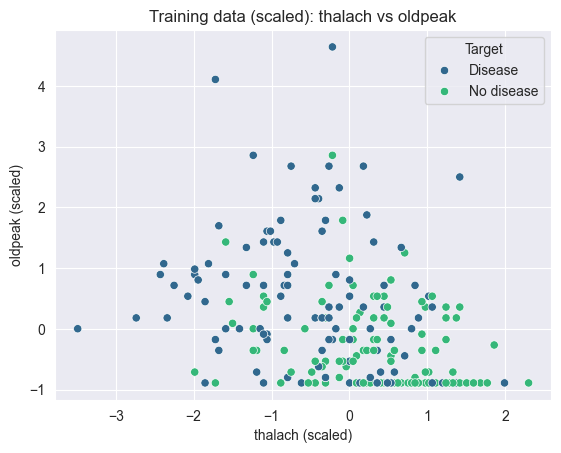

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

viz_cols = ['thalach', 'oldpeak']
scaler_viz = StandardScaler().fit(X_train[viz_cols])
X_train_viz = scaler_viz.transform(X_train[viz_cols])

sns.scatterplot(
    x=X_train_viz[:, 0],
    y=X_train_viz[:, 1],
    hue=(y_train.map({0:'No disease', 1:'Disease'}) if y_train.nunique()==2 else y_train),
    palette="viridis"
)
plt.xlabel(viz_cols[0] + " (scaled)")
plt.ylabel(viz_cols[1] + " (scaled)")
plt.title("Training data (scaled): " + viz_cols[0] + " vs " + viz_cols[1])
plt.legend(title="Target")
plt.show()

The conclusion from this plot is there is strong overlap in the middle so these two features by themselves are not enough to separate the classes, so in the modelling I will also include the categorical features. High thalach is a sign of no disease, while higher oldpeak shows disease.

## Modeling


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

num_cols = ['age','thalach','oldpeak']
cat_cols = ['sex','cp','slope','ca','thal','exang']

preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), cat_cols),
])

model = Pipeline([
    ('prep', preprocess),
    ('clf', KNeighborsClassifier(n_neighbors=10, weights='distance', p=2)),
])

model.fit(X_train, y_train)

pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))



Accuracy: 0.9180327868852459


In this step, I built a complete machine learning pipeline for heart disease prediction using the k-Nearest Neighbors algorithm. Numerical features were standardized and categorical features were one-hot encoded through a ColumnTransformer, ensuring that all variables were properly scaled and transformed for the model. Encoding was essential because machine learning algorithms can only process numerical data. Converting categorical variables into binary numeric columns allows the model to interpret them correctly and prevents it from assuming any false order among categories. Finally, I trained the model on the training data and evaluated it on the test set. The accuracy is pretty high which indicated strong predictive performance.

## How the encoded data looks

In [15]:
preprocess_fitted = model.named_steps['prep']

X_train_transformed = preprocess_fitted.transform(X_train)

if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()

encoded_feature_names = preprocess_fitted.named_transformers_['cat'].get_feature_names_out(cat_cols)

all_feature_names = num_cols + list(encoded_feature_names)

cleveland_df_encoded = pd.DataFrame(X_train_transformed, columns=all_feature_names)
print(cleveland_df_encoded.head())

        age   thalach   oldpeak  sex_1.0  cp_0  cp_1  cp_2  cp_3  slope_0  \
0 -0.729485  0.708371 -0.445445      1.0   0.0   0.0   0.0   1.0      0.0   
1  0.050166  0.222495 -0.891627      1.0   0.0   1.0   0.0   0.0      1.0   
2 -0.061212  0.399178 -0.891627      0.0   0.0   1.0   0.0   0.0      1.0   
3 -0.061212  0.266666 -0.891627      1.0   0.0   1.0   0.0   0.0      1.0   
4  0.272924 -1.190962 -0.713154      0.0   0.0   0.0   0.0   1.0      0.0   

   slope_1  slope_2  ca_0.0  ca_1.0  ca_2.0  ca_3.0  thal_0.0  thal_1.0  \
0      1.0      0.0     1.0     0.0     0.0     0.0       0.0       0.0   
1      0.0      0.0     1.0     0.0     0.0     0.0       1.0       0.0   
2      0.0      0.0     0.0     1.0     0.0     0.0       1.0       0.0   
3      0.0      0.0     1.0     0.0     0.0     0.0       0.0       0.0   
4      1.0      0.0     1.0     0.0     0.0     0.0       0.0       0.0   

   thal_2.0  exang_1.0  
0       1.0        0.0  
1       0.0        0.0  
2       0.0

Here is the result of applying standardization to numerical features and one-hot encoding to categorical features. The numerical columns (age, thalach, oldpeak) have been scaled to have a mean of 0 and a standard deviation of 1, which helps the model treat them equally regardless of their original units or ranges. The categorical columns (like sex, cp, slope, ca and thal) have been converted into multiple binary columns, each representing a category with values of 0 or 1. This transformation ensures that the model can interpret categorical data correctly without assuming any ordinal relationship. Together, these preprocessing steps prepare the data for efficient and accurate learning, contributing to the high predictive performance of the model.

## Evaluation


In [16]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report
)

pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, pred), 3))
print("Precision:", round(precision_score(y_test, pred, zero_division=0), 3))
print("Recall:", round(recall_score(y_test, pred, zero_division=0), 3))
print("F1:", round(f1_score(y_test, pred, zero_division=0), 3))

print("\nClassification report:\n")
print(classification_report(
    y_test, pred,
    labels=[0, 1],
    target_names=["No disease", "Disease"],
    digits=3,
    zero_division=0
))


Accuracy: 0.918
Precision: 0.897
Recall: 0.929
F1: 0.912

Classification report:

              precision    recall  f1-score   support

  No disease      0.938     0.909     0.923        33
     Disease      0.897     0.929     0.912        28

    accuracy                          0.918        61
   macro avg      0.917     0.919     0.918        61
weighted avg      0.919     0.918     0.918        61



The model’s performance metrics demonstrate strong predictive capabilities in detecting heart disease. It achieved an accuracy of 0.918, meaning it correctly classified about 92% of all cases. The precision (0.897) indicates that when the model predicts the presence of disease, it is correct nearly 90% of the time, while the recall (0.929) shows it successfully identifies about 93% of all actual disease cases. The F1-score (0.912) confirms the model’s robust and reliable performance. Additionally, the classification report shows consistently high scores for both classes (“Disease” and “No disease”), indicating the model performs well across different categories and is suitable for practical use in heart disease prediction.

## Inference example


In [17]:
import pandas as pd

selected = ["age","thalach","oldpeak","sex","cp","slope","ca","thal","exang"]

patient = {
    "age": 22,
    "thalach": 132,
    "oldpeak": 1.4,
    "sex": 1,
    "cp": 3,
    "slope": 0,
    "ca": 0,
    "thal": 0,
    "exang": 0
}

X_inf = pd.DataFrame([patient], columns=selected)

X_inf = X_inf[X_train.columns]

X_inf = X_inf.astype(X_train.dtypes.to_dict())

num_cols = ['age','thalach','oldpeak']
X_inf[num_cols] = X_inf[num_cols].apply(pd.to_numeric, errors='raise')

proba = model.predict_proba(X_inf)[0, 1]
pred = int(proba >= 0.5)

print(f"Probability of Disease: {proba:.3f}")
print(f"Predicted class: {pred}, The patient {'disease' if pred==1 else 'no disease'}")


Probability of Disease: 0.405
Predicted class: 0, The patient no disease


The model predicts that the patient has a 40.5% chance of having heart disease, which is below the 50% threshold. Therefore, the result is “No disease”. This shows that the model can give both a prediction and a probability.

In [18]:
import pandas as pd

selected = ["age","thalach","oldpeak","sex","cp","slope","ca","thal","exang"]

patient = {
    "age": 67,
    "thalach": 105,
    "oldpeak": 3.2,
    "sex": 1,
    "cp": 2,
    "slope": 2,
    "ca": 2,
    "thal": 2,
    "exang": 1
}

X_inf = pd.DataFrame([patient], columns=selected)

X_inf = X_inf[X_train.columns]

X_inf = X_inf.astype(X_train.dtypes.to_dict())

num_cols = ['age','thalach','oldpeak']
X_inf[num_cols] = X_inf[num_cols].apply(pd.to_numeric, errors='raise')

proba = model.predict_proba(X_inf)[0, 1]
pred = int(proba >= 0.5)

print(f"Probability of Disease: {proba:.3f}")
print(f"Predicted class: {pred}, The patient has {'disease' if pred==1 else 'no disease'}")


Probability of Disease: 1.000
Predicted class: 1, The patient has disease


The model predicts a 100% probability of heart disease, which is above the 50% threshold. Therefore, the result is “The patient has disease.” This shows a very high confidence in the prediction, indicating that the patient is very likely to have heart disease based on the given data.

## Data Provisioning (Merging with another dataset)

In [19]:
import pandas as pd

df_india = pd.read_csv("data/Cardiovascular_Disease_Dataset.csv")

# renaming the columns so they match with the UCI dataset
df_india = df_india.rename(columns={
    "gender": "sex",
    "chestpain": "cp",
    "restingBP": "trestbps",
    "serumcholestrol": "chol",
    "fastingbloodsugar": "fbs",
    "restingrelectro": "restecg",
    "maxheartrate": "thalach",
    "exerciseangia": "exang",
    "noofmajorvessels": "ca"
})
df_india["cp"]      = df_india["cp"].map({1:0, 2:1, 3:2, 4:3}).fillna(df_india["cp"])
df_india["slope"]   = df_india["slope"].map({1:0, 2:1, 3:2}).fillna(df_india["slope"])


# ensuring binary columns are 0/1 ints
for c in ["sex","fbs","exang","target"]:
    if c in df_india.columns:
        df_india[c] = (df_india[c] > 0).astype(int)

# dropping patientid
df_india = df_india.drop(columns=[c for c in ["patientid"] if c in df_india.columns])

In [20]:
df_india.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,target
0,53,1,1.0,171,0,0,1,147,0,5.3,2.0,3,1
1,40,1,0.0,94,229,0,1,115,0,3.7,0.0,1,0
2,49,1,1.0,133,142,0,0,202,1,5.0,0.0,0,0
3,43,1,0.0,138,295,1,1,153,0,3.2,1.0,2,1
4,31,1,0.0,199,0,0,2,136,0,5.3,2.0,2,1


## Checking for missing values

In [21]:
print(df_india.isna().sum())


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
target      0
dtype: int64


There are no missing values in this dataset that I need to deal with.

## Checking for duplicate rows

In [22]:
print("Num of duplicate rows", df_india.duplicated().sum())

Num of duplicate rows 0


There are no duplicate rows in this dataset.

## Count of positive and negative samples

In [23]:
df_india.target.value_counts()

target
1    580
0    420
Name: count, dtype: int64

The conclusion is that the dataset is somewhat balanced.

## Merging the two datasets

In [24]:
df_india["region"] = "india"
cleveland_df["region"] = "cleveland"

In [25]:
import pandas as pd
merged = pd.concat([df_india, cleveland_df], ignore_index=True)
merged = merged.drop(columns=["thal"])

In [26]:
merged.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,target,region
0,53.0,1.0,1.0,171.0,0.0,0.0,1,147.0,0.0,5.3,2.0,3.0,1,india
1,40.0,1.0,0.0,94.0,229.0,0.0,1,115.0,0.0,3.7,0.0,1.0,0,india
2,49.0,1.0,1.0,133.0,142.0,0.0,0,202.0,1.0,5.0,0.0,0.0,0,india
3,43.0,1.0,0.0,138.0,295.0,1.0,1,153.0,0.0,3.2,1.0,2.0,1,india
4,31.0,1.0,0.0,199.0,0.0,0.0,2,136.0,0.0,5.3,2.0,2.0,1,india


The merged dataset does not have column **thal** any more because the second dataset does not have such column.

### Range of predictors

In [27]:
ranges = merged.apply(pd.to_numeric, errors="coerce").agg(["min","max"]).T
print(ranges)

           min    max
age       20.0   80.0
sex        0.0    1.0
cp         0.0    3.0
trestbps  94.0  200.0
chol       0.0  602.0
fbs        0.0    1.0
restecg    0.0    2.0
thalach   71.0  202.0
exang      0.0    1.0
oldpeak    0.0    6.2
slope      0.0    2.0
ca         0.0    3.0
target     0.0    1.0
region     NaN    NaN


In conclusion, the range of the different features is pretty similar to the range in the Cleveland dataset.

### Count of positive and negative samples in the merged dataset

In [28]:
merged.target.value_counts()

target
1    719
0    584
Name: count, dtype: int64

#### Visualisation

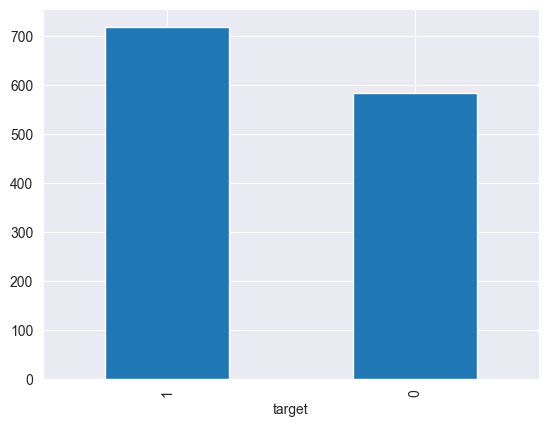

In [29]:
merged.target.value_counts().plot(kind="bar");

The merged dataset is somewhat balanced.

## Boxplots for numerical values

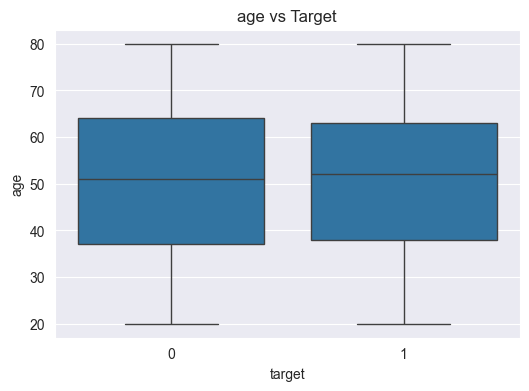

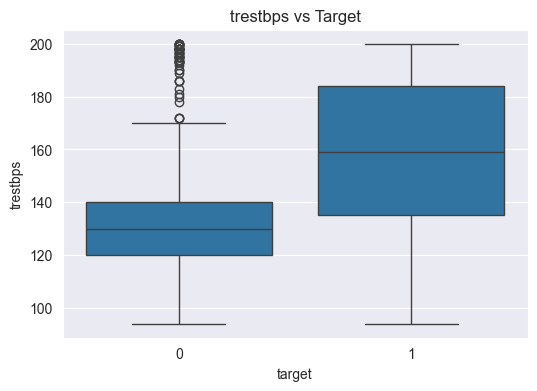

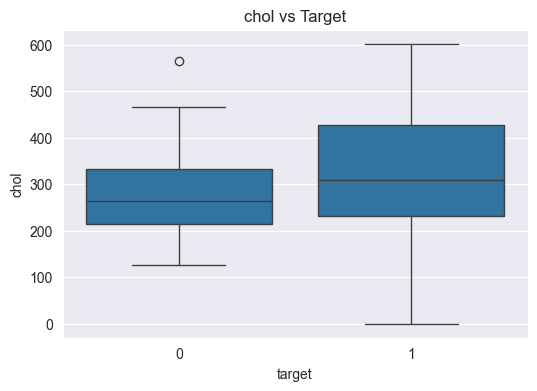

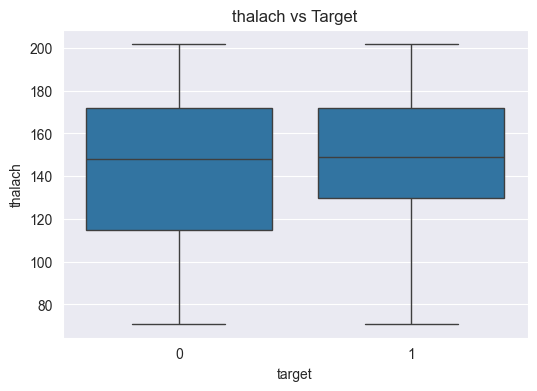

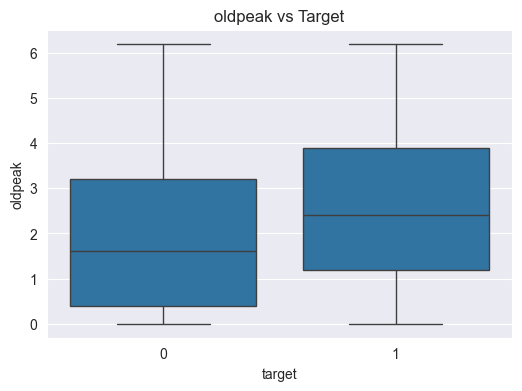

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for feature in numeric_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='target', y=feature, data=merged)
    plt.title(f'{feature} vs Target')
    plt.show()


The boxplots compare numeric variables to the target variable. The median differences between **trestbps** and **oldpeak** and the target show that these features are the most important numeric predictors. In conclusion, patients who have CAD have higher resting blood pressure. A higher oldpeak reflects abnormal heart response during exercise which is a strong sign of CAD. These two features show strong class separation. They are likely to be highly predictive in the machine learning model.

## Bar charts for categorical features

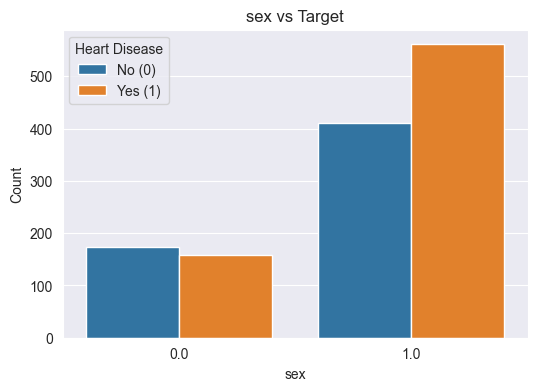

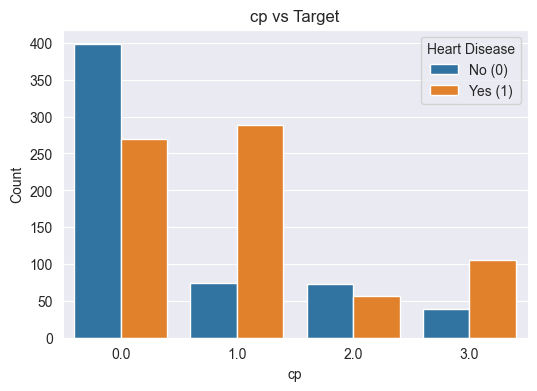

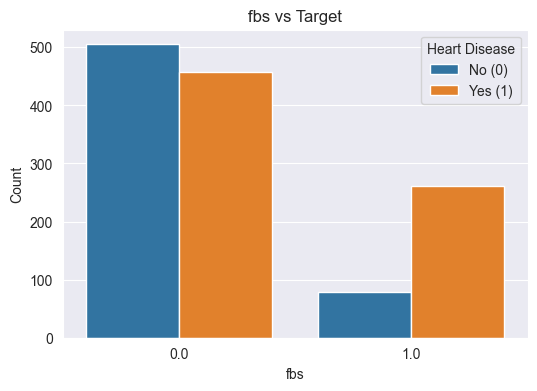

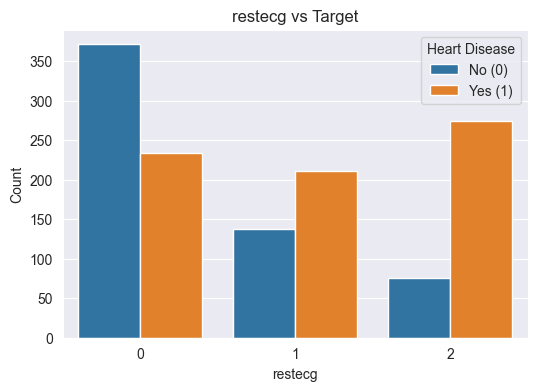

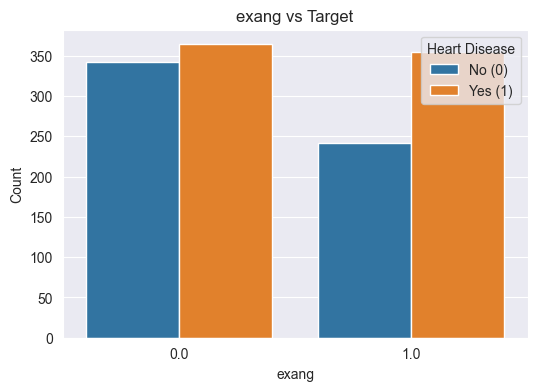

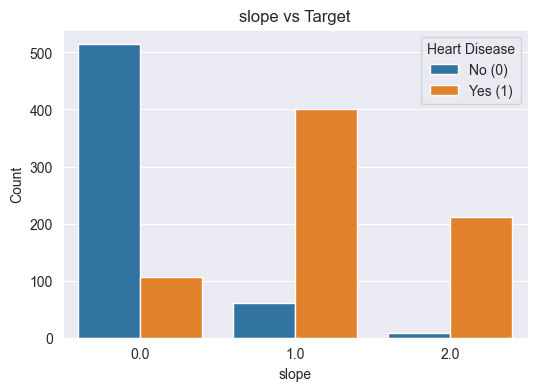

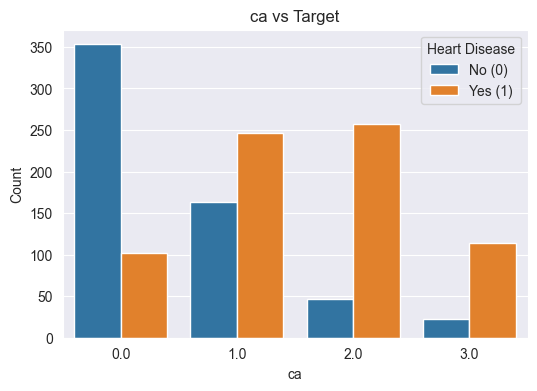

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca']

for feature in categorical_features:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=merged, x=feature, hue='target')
    plt.title(f'{feature} vs Target')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.legend(title='Heart Disease', labels=['No (0)', 'Yes (1)'])
    plt.show()


 Chest pain is one of the most important predictors with type 3 being strongly associated with heart disease. Sex is also important because men are more likely to have CAD than women. The slope is another key indicator because patients with a flat slope (value 1) are more likely to have heart disease, while those with an upsloping slope (value 0) are less likely. The number of major vessels (ca) also shows a clear pattern: having zero visible vessels is linked to low risk, while having one or more vessels is associated with a higher risk. Elevated fasting blood sugar seems to be associated with a higher risk of heart disease in this dataset. As ECG results become more abnormal, the likelihood of heart disease increases significantly. This makes restecg a potentially strong predictive feature in a heart disease model.

## Correlation matrix for merged dataset

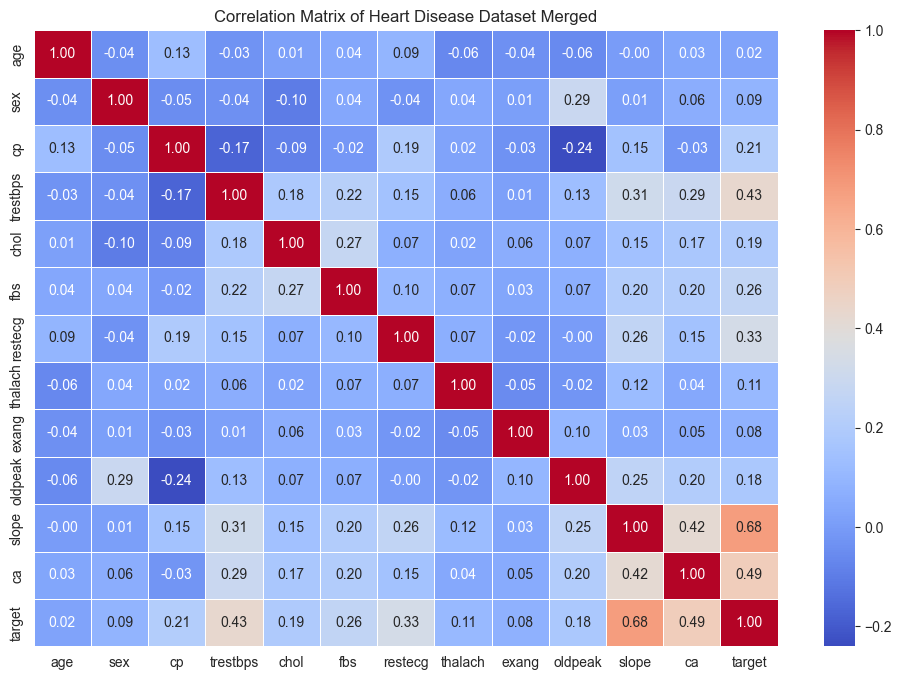

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = merged.select_dtypes(include=['number'])

corr = numeric_df.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Heart Disease Dataset Merged")
plt.show()


The correlation matrix shows that the features that have the highest positive correlation with the target variable are **trestbps**, **fbs**, **restegc**, **slope**, **ca**.

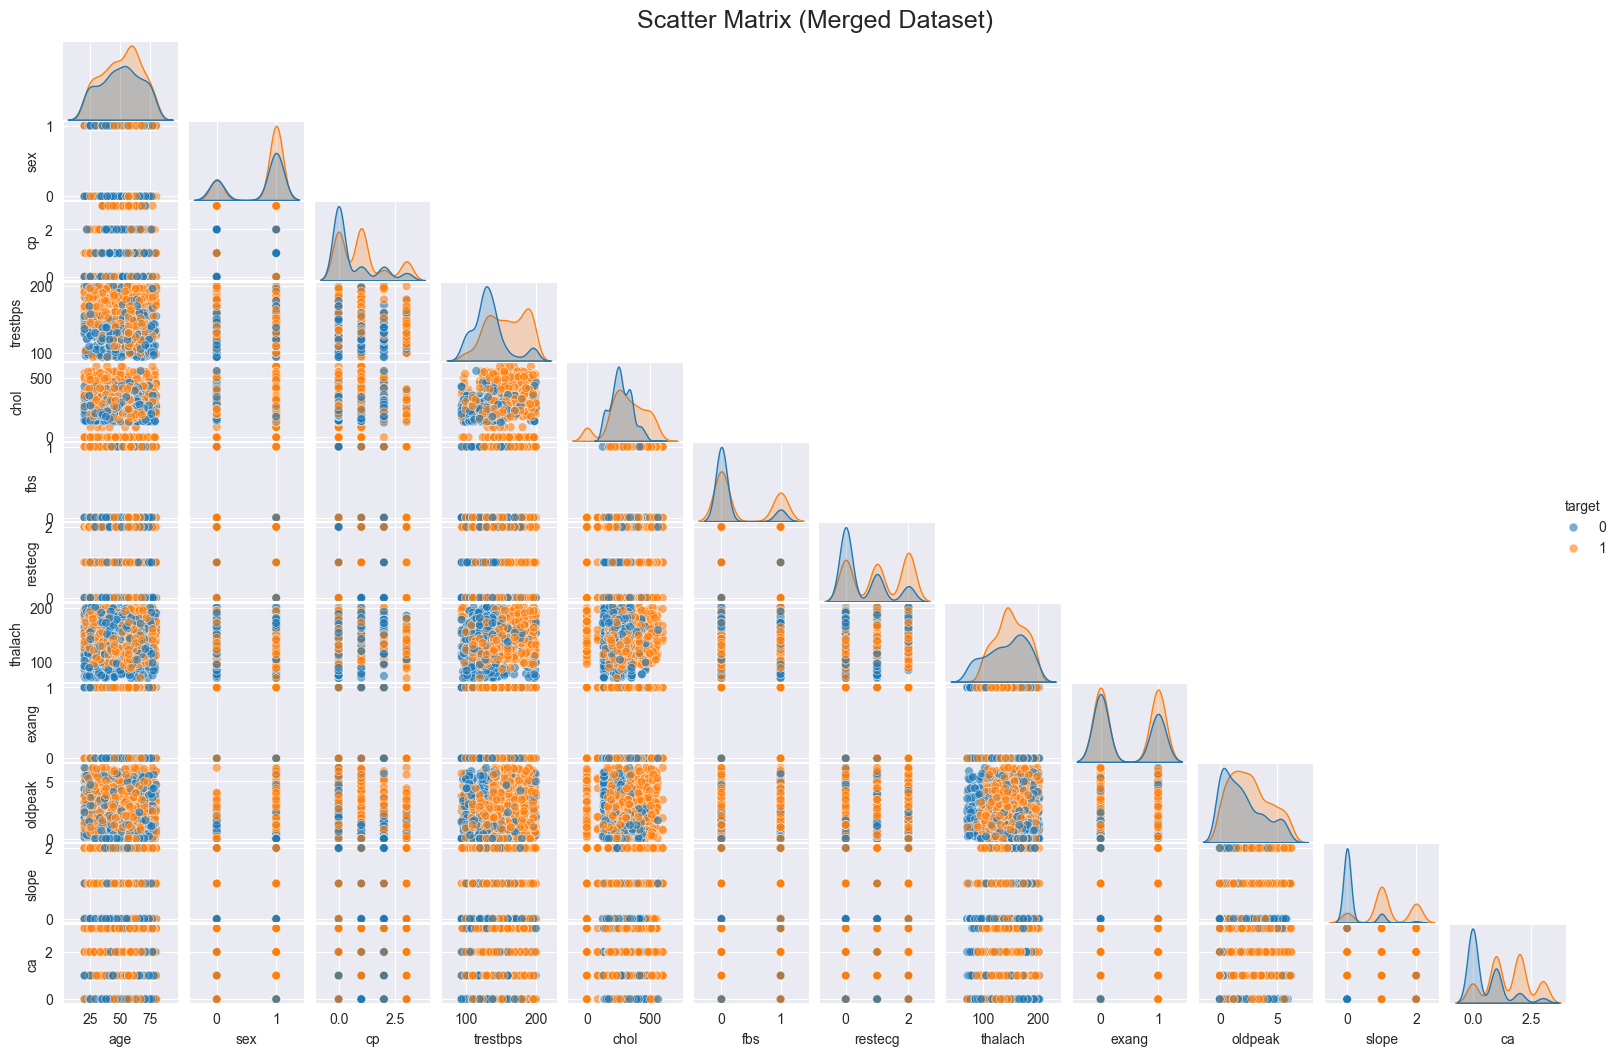

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(
    merged,
    hue='target',
    diag_kind='kde',
    corner=True,
    plot_kws={'s': 40, 'alpha': 0.6}
)

plt.gcf().set_size_inches(16, 10)
plt.suptitle("Scatter Matrix (Merged Dataset)", fontsize=18, y=1.02)
plt.show()


The conclusion from the scatter matrix is that lower thalach indicated higher likelihood of CAD. Higher oldpeak values, higher ca (more blocked vessels) are linked to heart disease. Value 1 foe exang (presence of angina during exercise) shows higher risk. CP (chest pain) correlates strongly with the target. 

## Feature selection

In [34]:
features = ["trestbps", "oldpeak", "sex", "slope", "ca", "fbs", "restecg"]
target = "target"

X = merged[features].copy()
y = merged[target].copy()


I chose these features because according to the visualisations they are supposed to have the highest predictive value out of all for this dataset.

## Splitting into train/test set

In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("There are in total", len(X), "observations, of which", len(X_train), "are now in the train set and", len(X_test), "in the test set.")

There are in total 1303 observations, of which 1042 are now in the train set and 261 in the test set.


## Scaling

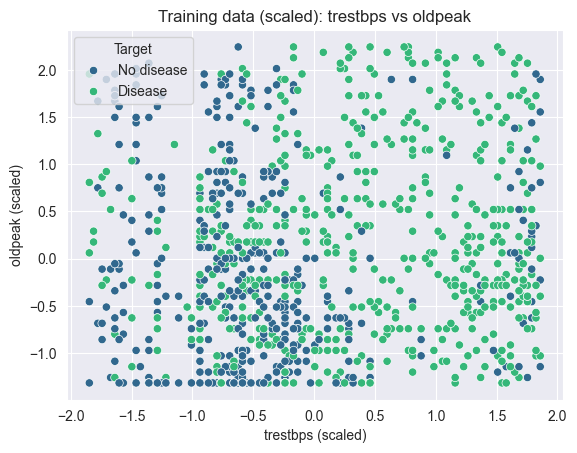

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

viz_cols = ['trestbps', 'oldpeak']
scaler_viz = StandardScaler().fit(X_train[viz_cols])
X_train_viz = scaler_viz.transform(X_train[viz_cols])

sns.scatterplot(
    x=X_train_viz[:, 0],
    y=X_train_viz[:, 1],
    hue=(y_train.map({0:'No disease', 1:'Disease'}) if y_train.nunique()==2 else y_train),
    palette="viridis"
)
plt.xlabel(viz_cols[0] + " (scaled)")
plt.ylabel(viz_cols[1] + " (scaled)")
plt.title("Training data (scaled): " + viz_cols[0] + " vs " + viz_cols[1])
plt.legend(title="Target")
plt.show()

The conclusion from this plot is there is strong overlap in the middle so these two features by themselves are not enough to separate the classes, so in the modelling I will also include the categorical features.

## Modeling

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

num_cols = ['trestbps','oldpeak']
cat_cols = ['sex','slope','ca','fbs','restecg']

preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), cat_cols),
])

model = Pipeline([
    ('prep', preprocess),
    ('clf', KNeighborsClassifier(n_neighbors=10, weights='distance', p=2)),
])

model.fit(X_train, y_train)

pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))



Accuracy: 0.9003831417624522


In this step, I built a complete machine learning pipeline for heart disease prediction using the k-Nearest Neighbors algorithm. Numerical features were standardized and categorical features were one-hot encoded through a ColumnTransformer, ensuring that all variables were properly scaled and transformed for the model. Encoding was essential because machine learning algorithms can only process numerical data. Converting categorical variables into binary numeric columns allows the model to interpret them correctly and prevents it from assuming any false order among categories. Finally, I trained the model on the training data and evaluated it on the test set. The accuracy is pretty high which indicated strong predictive performance.

## How the encoded and scaled data looks like

In [38]:
preprocess_fitted = model.named_steps['prep']

X_train_transformed = preprocess_fitted.transform(X_train)

if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()

encoded_feature_names = preprocess_fitted.named_transformers_['cat'].get_feature_names_out(cat_cols)

all_feature_names = num_cols + list(encoded_feature_names)

merged_df_encoded = pd.DataFrame(X_train_transformed, columns=all_feature_names)
print(merged_df_encoded.head())

   trestbps   oldpeak  sex_1.0  slope_0.0  slope_1.0  slope_2.0  ca_0.0  \
0 -1.287469 -0.570722      1.0        1.0        0.0        0.0     1.0   
1  1.194150  0.750817      1.0        0.0        1.0        0.0     0.0   
2  1.788341 -0.455806      1.0        0.0        1.0        0.0     0.0   
3 -0.238897 -1.087846      1.0        0.0        1.0        0.0     1.0   
4  0.250436  1.497773      1.0        0.0        1.0        0.0     0.0   

   ca_1.0  ca_2.0  ca_3.0  fbs_1.0  restecg_0  restecg_1  restecg_2  
0     0.0     0.0     0.0      0.0        1.0        0.0        0.0  
1     0.0     1.0     0.0      0.0        0.0        0.0        1.0  
2     0.0     1.0     0.0      0.0        0.0        0.0        1.0  
3     0.0     0.0     0.0      0.0        1.0        0.0        0.0  
4     1.0     0.0     0.0      0.0        0.0        1.0        0.0  


Here is the result of applying standardization to numerical features and one-hot encoding to categorical features. The numerical columns (oldpeak, trestbps) have been scaled to have a mean of 0 and a standard deviation of 1, which helps the model treat them equally regardless of their original units or ranges. The categorical columns (like sex, slope, ca, fbs, restegc) have been converted into multiple binary columns, each representing a category with values of 0 or 1. This transformation ensures that the model can interpret categorical data correctly without assuming any ordinal relationship. Together, these preprocessing steps prepare the data for efficient and accurate learning, contributing to the high predictive performance of the model.

## Evaluation

In [39]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report
)

pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, pred), 3))
print("Precision:", round(precision_score(y_test, pred, zero_division=0), 3))
print("Recall:", round(recall_score(y_test, pred, zero_division=0), 3))
print("F1:", round(f1_score(y_test, pred, zero_division=0), 3))

print("\nClassification report:\n")
print(classification_report(
    y_test, pred,
    labels=[0, 1],
    target_names=["No disease", "Disease"],
    digits=3,
    zero_division=0
))


Accuracy: 0.9
Precision: 0.934
Recall: 0.882
F1: 0.907

Classification report:

              precision    recall  f1-score   support

  No disease      0.864     0.923     0.893       117
     Disease      0.934     0.882     0.907       144

    accuracy                          0.900       261
   macro avg      0.899     0.903     0.900       261
weighted avg      0.903     0.900     0.901       261



## Inference Example

In [40]:
import pandas as pd

selected = ['trestbps','oldpeak','sex','slope','ca','fbs','restecg']

patient_pos = {
    "trestbps": 160,
    "oldpeak": 3.2,
    "sex": 1,
    "slope": 2,
    "ca": 2,
    "fbs": 1,
    "restecg": 2
}

X_inf_pos = pd.DataFrame([patient_pos], columns=selected)

proba_pos = model.predict_proba(X_inf_pos)[0, 1]
pred_pos = int(proba_pos >= 0.5)

print(f"Probability of Disease: {proba_pos:.3f}")
print(f"Predicted class: {pred_pos}  →  The patient {'has disease' if pred_pos==1 else 'has no disease'}")


Probability of Disease: 1.000
Predicted class: 1  →  The patient has disease


The model predicts a 100% probability of heart disease, which is above the 50% threshold. Therefore, the result is “The patient has disease.” This shows a very high confidence in the prediction, indicating that the patient is very likely to have heart disease based on the given data.

In [41]:
import pandas as pd

selected = ['trestbps','oldpeak','sex','slope','ca','fbs','restecg']

patient_neg = {
    "trestbps": 118,
    "oldpeak": 0.0,
    "sex": 0,
    "slope": 1,
    "ca": 0,
    "fbs": 0,
    "restecg": 0
}

X_inf_neg = pd.DataFrame([patient_neg], columns=selected)

proba_neg = model.predict_proba(X_inf_neg)[0, 1]
pred_neg = int(proba_neg >= 0.5)

print(f"Probability of Disease: {proba_neg:.3f}")
print(f"Predicted class: {pred_neg}  →  The patient {'has disease' if pred_neg==1 else 'has no disease'}")


Probability of Disease: 0.072
Predicted class: 0  →  The patient has no disease


The model predicts that the patient has a 7,2% chance of having heart disease, which is well below the 50% threshold. Therefore, the result is “No disease”. This shows that the model can give both a prediction and a probability.

## Conclusion and comparison kNN

In the first part of the project, I used the Cleveland Heart Disease dataset from the UCI repository, which includes 303 patients. During data visualization, I identified that the most predictive features for heart disease were age, thalach, oldpeak, exang, sex, cp, slope, ca, and thal. The trained model performed very well, achieving an accuracy of approximately 0.92, with high precision, recall, and F1-score, indicating strong predictive performance.

To compare performance on a larger dataset, I merged the Cleveland dataset with another cardiovascular dataset from India. Most of the columns were similar, but a few column names differed, so I standardized them according to the Cleveland naming convention. The Indian dataset did not include the thal column, so this feature was removed from the merged dataset. I also added a new column called region to indicate whether each record came from Cleveland or India.

After merging, I noticed that the predictive importance of some features changed. Similar to the Cleveland dataset, sex, slope, ca, and oldpeak remained highly influential, but additional features like trestbps, restecg, and fbs also showed strong predictive value. The model trained on the merged dataset achieved an accuracy of around 0.9, with precision, recall, and F1-scores remaining high and close to those of the Cleveland-only model.

Overall, the results suggest that the model generalizes well to data from different regions and maintains strong performance even when combining datasets with slightly different structures.

## Decision Trees Modeling

### Feature selection (Cleveland set)


In [87]:
features = ["age", "thalach", "oldpeak", "exang", "sex", "cp", "slope", "ca", "thal"]
target = "target"

X = cleveland_df[features].copy()
y = cleveland_df[target].copy()


### Splitting into train/test set

In [88]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("There are in total", len(X), "observations, of which", len(X_train), "are now in the train set and", len(X_test), "in the test set.")

There are in total 303 observations, of which 242 are now in the train set and 61 in the test set.


### Modelling

In [93]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

num_cols = ['age', 'thalach', 'oldpeak']
cat_cols = ['sex', 'cp', 'slope', 'ca', 'thal', 'exang']

preprocess = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary', sparse_output=False), cat_cols),
    ]
)

clf = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    min_samples_leaf=5,
    random_state=42
)

model = Pipeline([
    ('prep', preprocess),
    ('clf', clf),
])

model.fit(X_train, y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['age', 'thalach',
                                                   'oldpeak']),
                                                 ('cat',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['sex', 'cp', 'slope', 'ca',
                                                   'thal', 'exang'])])),
                ('clf',
                 DecisionTreeClassifier(max_depth=3, min_samples_leaf=8,
                                        random_state=42))])

### Evaluation

In [94]:
pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))


Accuracy: 0.8688524590163934
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        33
           1       0.86      0.86      0.86        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



The accuracy for the decision tree model for the Cleveland dataset when the max_depth is 6 is lower compared to when it is 3. This happens because the dataset is rather small and smaller depth keeps the model simple enough to generalize and prevents overfitting. If the depth is too big the model learns noice and tiny details in the training data.

### Visualisation of decision tree

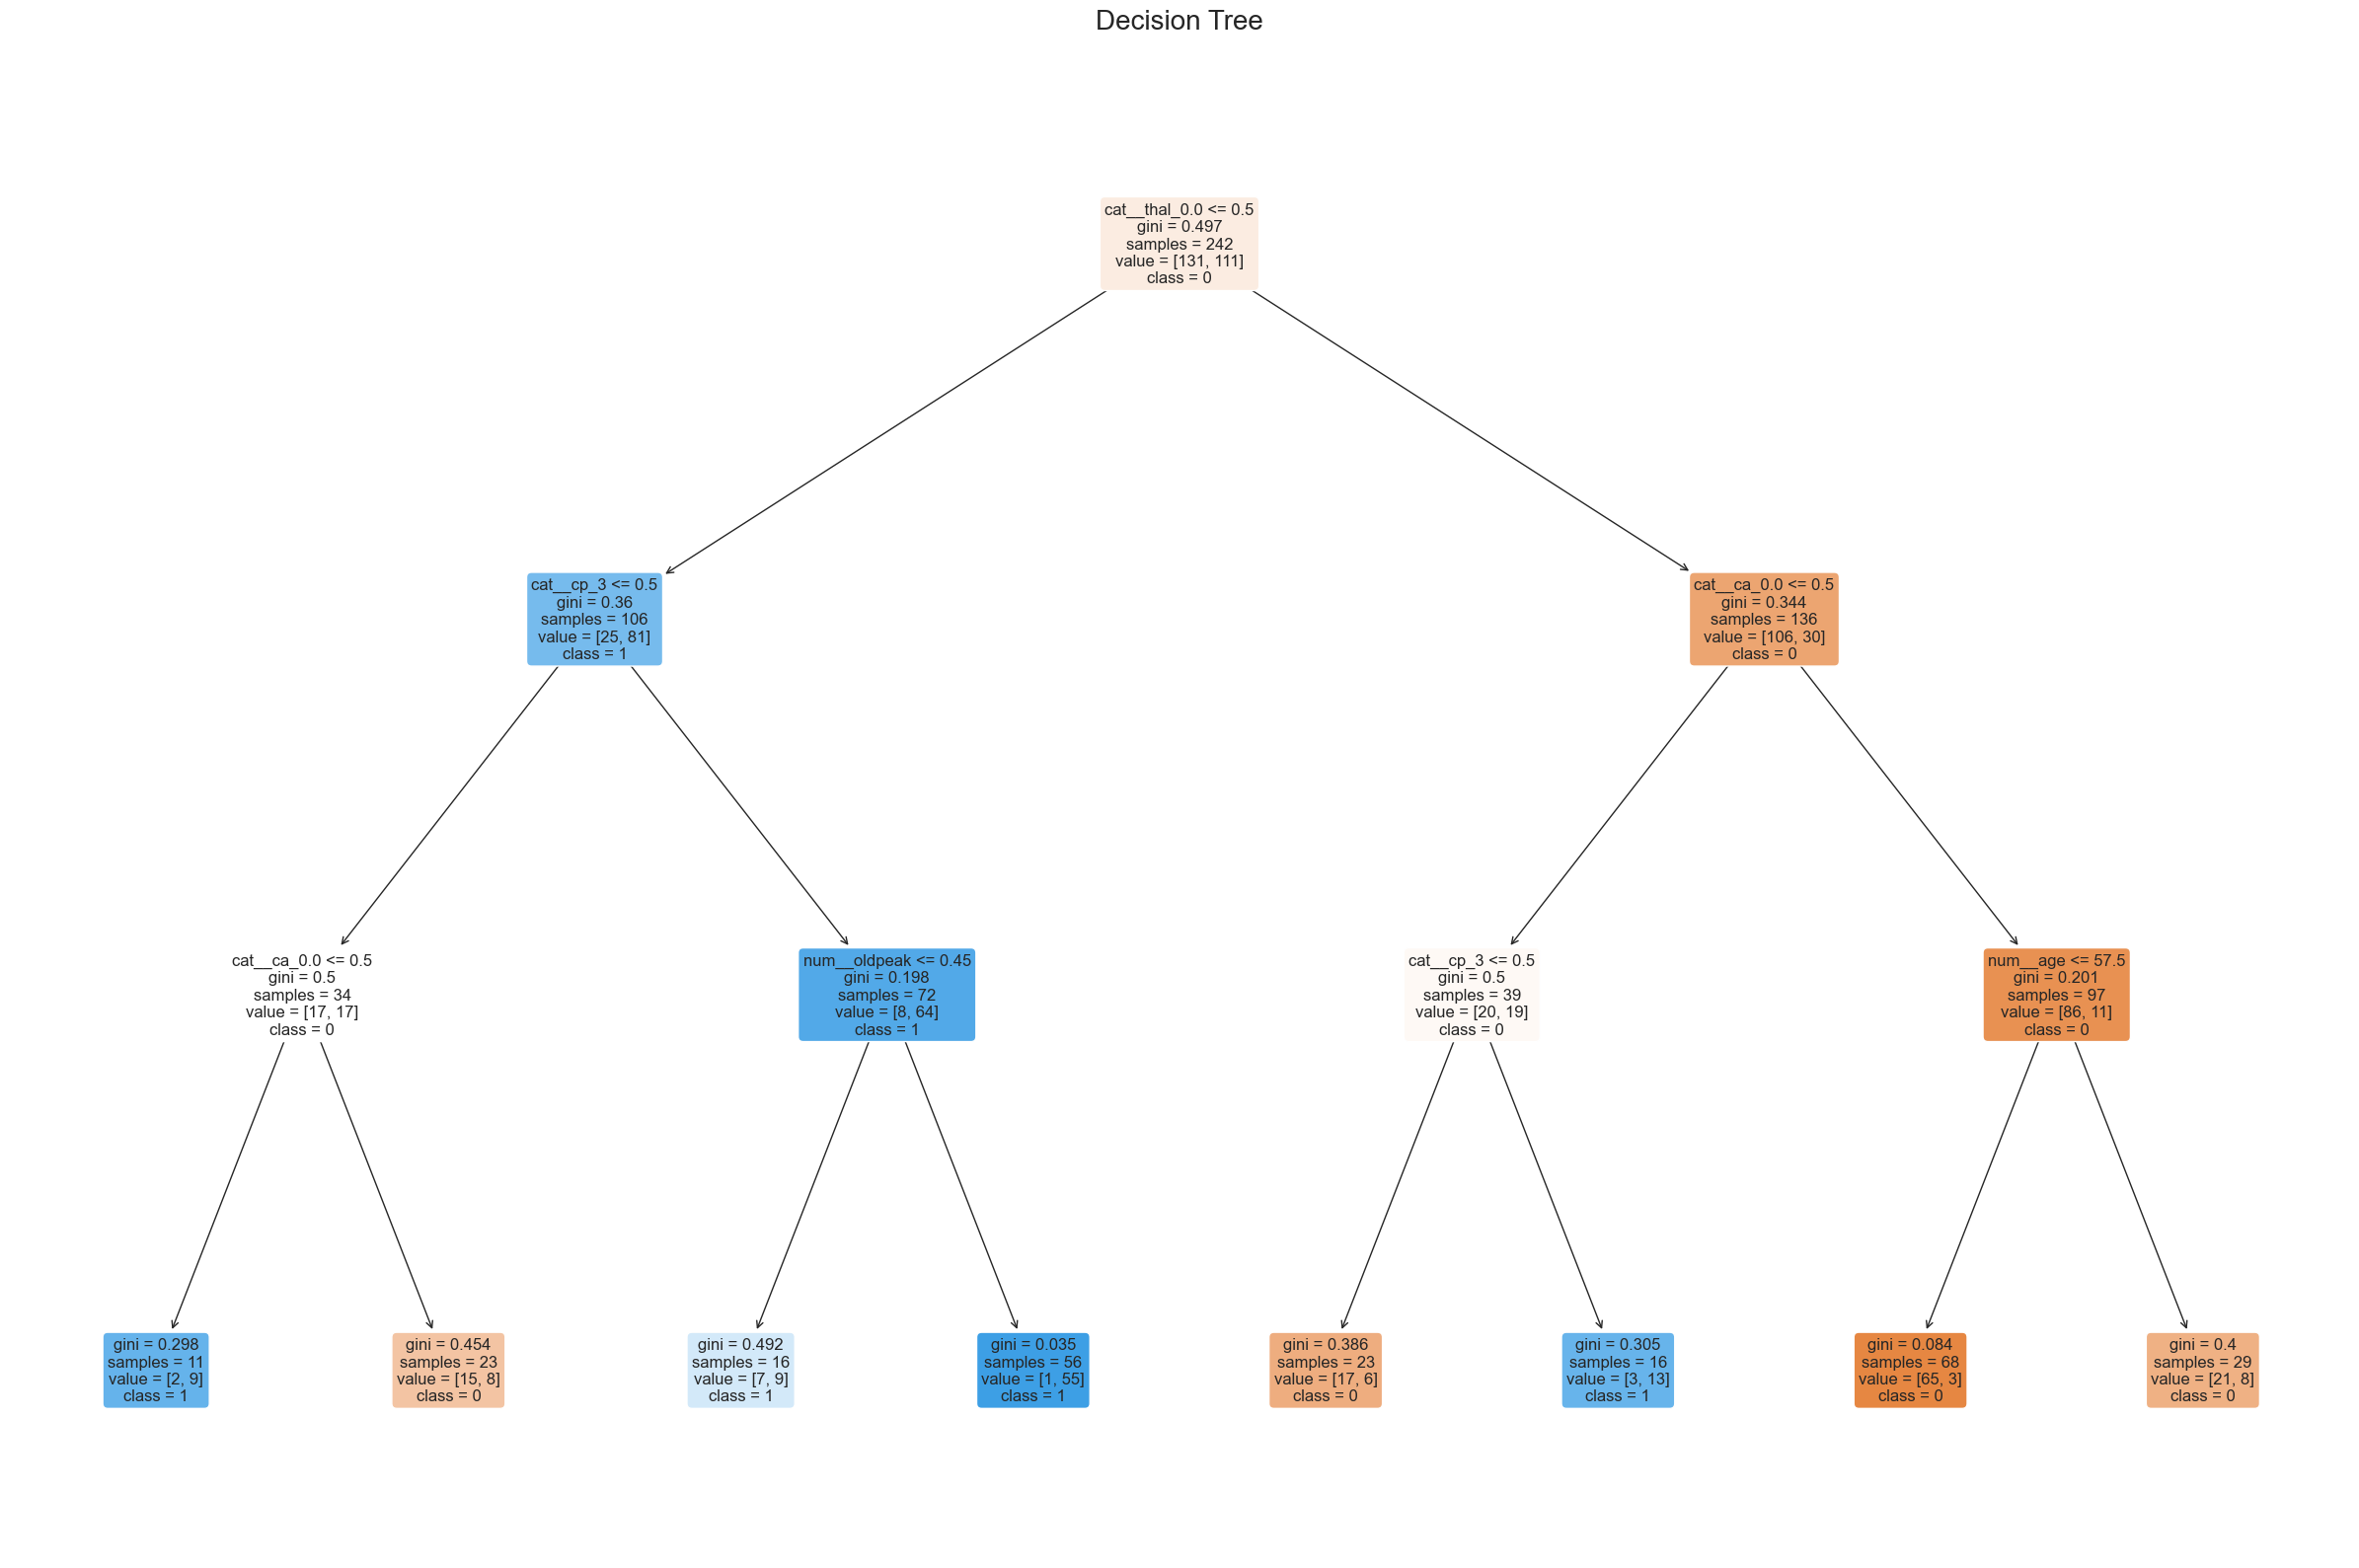

In [95]:
feature_names = model.named_steps['prep'].get_feature_names_out()

plt.figure(figsize=(24, 16))
plot_tree(
    model.named_steps['clf'],
    max_depth=3,
    feature_names=feature_names,
    class_names=[str(c) for c in np.unique(y_train)],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title("Decision Tree", fontsize=20, pad=20)
plt.tight_layout()
plt.show()


### Inference example for negative result

In [96]:
import pandas as pd

selected = ["age","thalach","oldpeak","sex","cp","slope","ca","thal","exang"]

patient = {
    "age": 22,
    "thalach": 132,
    "oldpeak": 1.4,
    "sex": 1,
    "cp": 3,
    "slope": 0,
    "ca": 0,
    "thal": 0,
    "exang": 0
}

X_inf = pd.DataFrame([patient], columns=selected)
X_inf = X_inf[X_train.columns]
X_inf = X_inf.astype(X_train.dtypes.to_dict())

num_cols = ['age','thalach','oldpeak']
X_inf[num_cols] = X_inf[num_cols].apply(pd.to_numeric, errors='raise')

proba = model.predict_proba(X_inf)[0, 1]
pred = int(proba >= 0.5)

print(f"Probability of Disease: {proba:.3f}")
print(f"Predicted Class: {pred} → The patient has {'heart disease' if pred==1 else 'no heart disease'}.")


Probability of Disease: 0.044
Predicted Class: 0 → The patient has no heart disease.


This is an example for a patient who does not have heart disease.

### Inference example for positive result

In [97]:
import pandas as pd

selected = ["age","thalach","oldpeak","sex","cp","slope","ca","thal","exang"]

patient = {    "age": 67,    "thalach": 105,    "oldpeak": 3.2,    "sex": 1,    "cp": 2,    "slope": 2,    "ca": 2,    "thal": 2,    "exang": 1}

X_inf = pd.DataFrame([patient], columns=selected)
X_inf = X_inf[X_train.columns]
X_inf = X_inf.astype(X_train.dtypes.to_dict())

num_cols = ['age','thalach','oldpeak']
X_inf[num_cols] = X_inf[num_cols].apply(pd.to_numeric, errors='raise')

proba = model.predict_proba(X_inf)[0, 1]
pred = int(proba >= 0.5)

print(f"Probability of Disease: {proba:.3f}")
print(f"Predicted Class: {pred} → The patient has {'heart disease' if pred==1 else 'no heart disease'}.")


Probability of Disease: 0.818
Predicted Class: 1 → The patient has heart disease.


This is an example of a patient who has heart disease.

## Feature selection(merged set)

In [98]:
features = ["trestbps", "oldpeak", "sex", "slope", "ca", "fbs", "restecg"]
target = "target"

X = merged[features].copy()
y = merged[target].copy()


## Splitting into train/test set

In [99]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("There are in total", len(X), "observations, of which", len(X_train), "are now in the train set and", len(X_test), "in the test set.")

There are in total 1303 observations, of which 1042 are now in the train set and 261 in the test set.


## Modelling 

In [112]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

num_cols = ['trestbps', 'oldpeak']
cat_cols = ['sex', 'fbs', 'slope', 'ca', 'restecg']

preprocess = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary', sparse_output=False), cat_cols),
    ]
)

clf = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    min_samples_leaf=5,
    random_state=42
)

model = Pipeline([
    ('prep', preprocess),
    ('clf', clf),
])

model.fit(X_train, y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['trestbps', 'oldpeak']),
                                                 ('cat',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['sex', 'fbs', 'slope', 'ca',
                                                   'restecg'])])),
                ('clf',
                 DecisionTreeClassifier(max_depth=4, min_samples_leaf=5,
                                        random_state=42))])

In [113]:
pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))


Accuracy: 0.9233716475095786
              precision    recall  f1-score   support

           0       0.90      0.93      0.92       117
           1       0.94      0.92      0.93       144

    accuracy                           0.92       261
   macro avg       0.92      0.92      0.92       261
weighted avg       0.92      0.92      0.92       261



The model shows a how accuracy of around 92 %. This is higher for the mergen dataset compared to the Cleveland dataset, because the merged one has more examples per leaf and less overfitting happens. The more data we have , the better is the generalization so the test performance is higher. Max_depth of 4 produces most trustworthy results as it increased the probability in inference examples is either 0 or 1. 

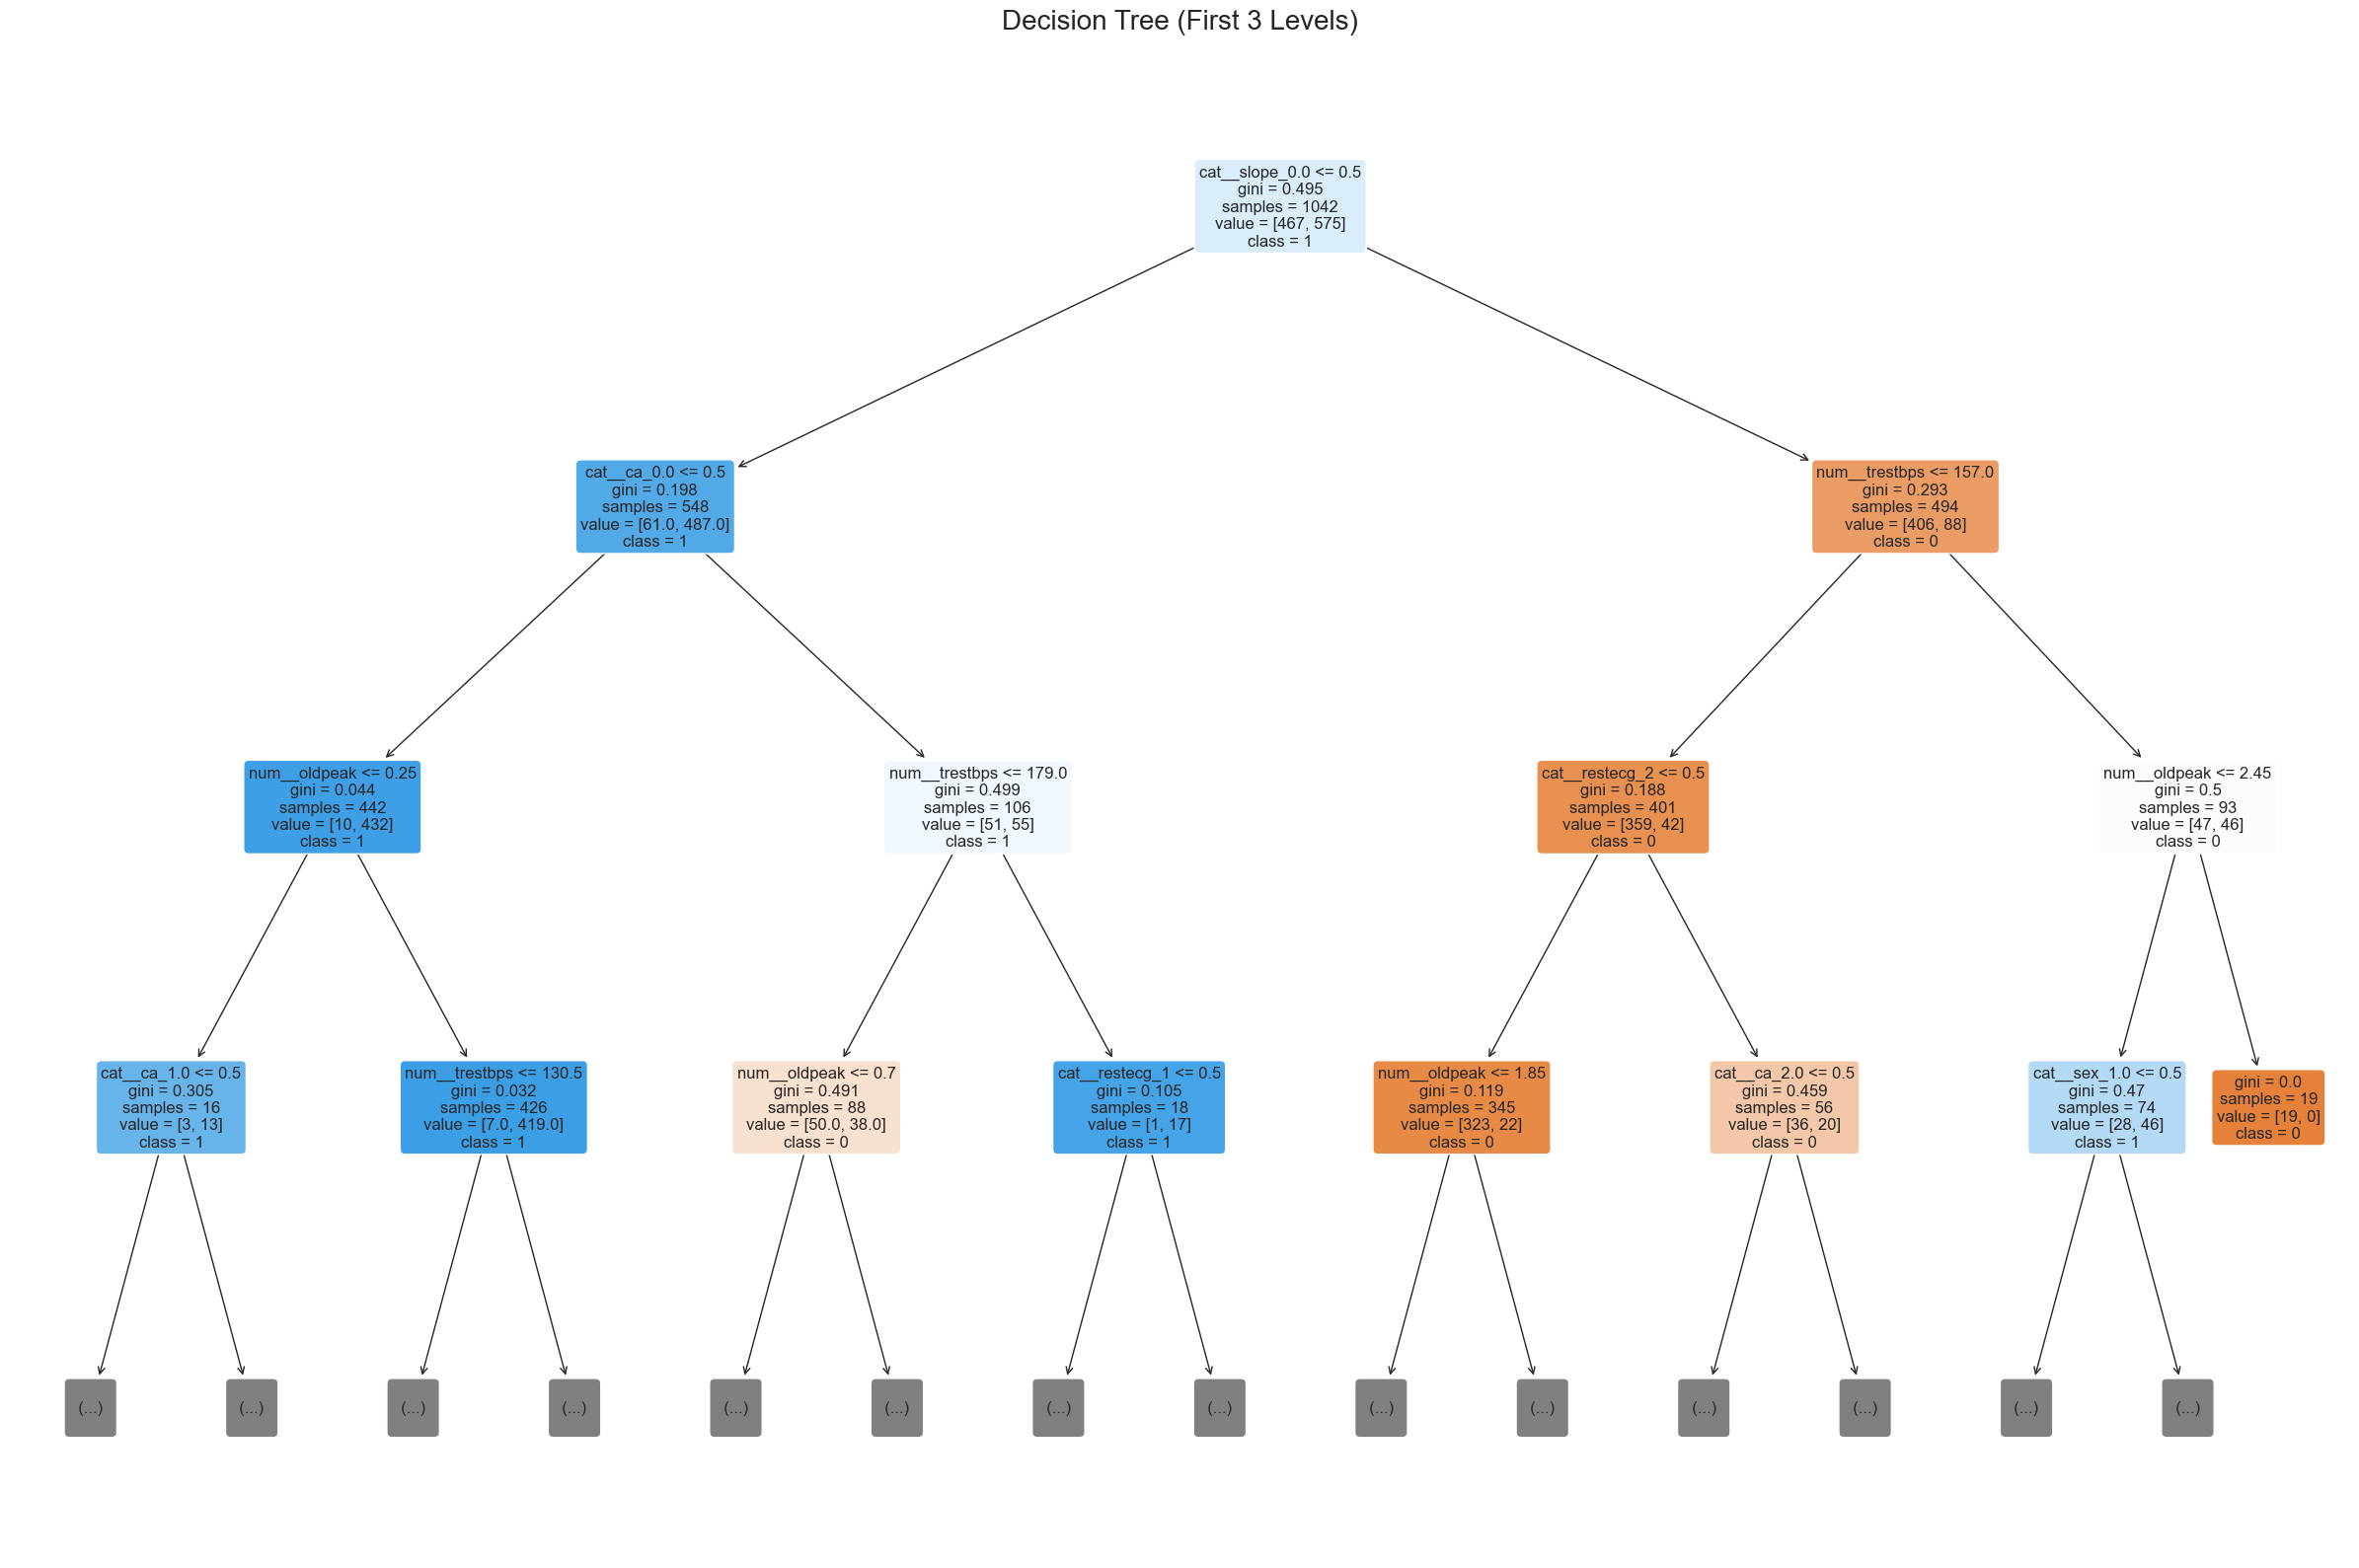

In [106]:
feature_names = model.named_steps['prep'].get_feature_names_out()

plt.figure(figsize=(24, 16))
plot_tree(
    model.named_steps['clf'],
    max_depth=3,
    feature_names=feature_names,
    class_names=[str(c) for c in np.unique(y_train)],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title("Decision Tree (First 3 Levels)", fontsize=20, pad=20)
plt.tight_layout()
plt.show()


In [114]:
import pandas as pd

selected = ['trestbps','oldpeak','sex','slope','ca','fbs','restecg']

patient_pos = {
    "trestbps": 160,
    "oldpeak": 3.2,
    "sex": 1,
    "slope": 2,
    "ca": 2,
    "fbs": 1,
    "restecg": 2
}

X_inf_pos = pd.DataFrame([patient_pos], columns=selected)

proba_pos = model.predict_proba(X_inf_pos)[0, 1]
pred_pos = int(proba_pos >= 0.5)

print(f"Probability of Disease: {proba_pos:.3f}")
print(f"Predicted class: {pred_pos}  →  The patient {'has disease' if pred_pos==1 else 'has no disease'}")


Probability of Disease: 0.994
Predicted class: 1  →  The patient has disease


This is an example for a patient who has heart disease.

In [115]:
import pandas as pd

selected = ['trestbps','oldpeak','sex','slope','ca','fbs','restecg']

patient_neg = {
    "trestbps": 118,
    "oldpeak": 0.0,
    "sex": 0,
    "slope": 1,
    "ca": 0,
    "fbs": 0,
    "restecg": 0
}

X_inf_neg = pd.DataFrame([patient_neg], columns=selected)

proba_neg = model.predict_proba(X_inf_neg)[0, 1]
pred_neg = int(proba_neg >= 0.5)

print(f"Probability of Disease: {proba_neg:.3f}")
print(f"Predicted class: {pred_neg}  →  The patient {'has disease' if pred_neg==1 else 'has no disease'}")


Probability of Disease: 0.167
Predicted class: 0  →  The patient has no disease


This is an exmaple for a patient who does not have heart disease.

### Why probability of 0 and 1 happens?
Decision Trees give 0 or 1 probabilities because each leaf node predicts the class ratio of the training samples inside it. If all samples in that leaf belong to one class (a pure leaf), the ratio is 0 or 1.
This happens often with small or deep trees. This can be fixed through using Random Forest algorithm - averaging many trees smooths out extreme probabilities. Tuning the max_depth also helps as it forces the tree to learn broad, general rules instead of detailed ones.

## Comparison of Decision Tree model for the Cleveland and merged dataset
The model for the merged dataset shows higher accuracy, precision, recall and F1 than the smaller Cleveland dataset because it has more instances. 300 examples is a very little data for the decision tree to learn stable decision boundaries. When the dataset is large, the tree can find stable, recurring patterns, therefore the generalization is better.

# Random forest

### Feature selection (Cleveland dataset)

In [116]:
features = ["age", "thalach", "oldpeak", "exang", "sex", "cp", "slope", "ca", "thal"]
target = "target"

X = cleveland_df[features].copy()
y = cleveland_df[target].copy()


### Splitting into train/test set

In [117]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("There are in total", len(X), "observations, of which", len(X_train), "are now in the train set and", len(X_test), "in the test set.")

There are in total 303 observations, of which 242 are now in the train set and 61 in the test set.


### Modelling

In [128]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

num_cols = ['age', 'thalach', 'oldpeak']
cat_cols = ['sex', 'cp', 'slope', 'ca', 'thal', 'exang']

preprocess = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary', sparse_output=False), cat_cols),
    ]
)
rf_clf = RandomForestClassifier(
    n_estimators=200,
    criterion='gini',
    max_depth=3,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model = Pipeline([
    ('prep', preprocess),
    ('clf', rf_clf),
])

rf_model.fit(X_train, y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['age', 'thalach',
                                                   'oldpeak']),
                                                 ('cat',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['sex', 'cp', 'slope', 'ca',
                                                   'thal', 'exang'])])),
                ('clf',
                 RandomForestClassifier(max_depth=3, min_samples_leaf=5,
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])

### Evaluation

In [129]:
pred = rf_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.8852459016393442
              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



The accuracy of the random forest model for the Cleveland set is high - around 89%. This is a slight increase compared to the decision tree model with accuracy of 87%.

### Inference examples

In [130]:
import pandas as pd

patient = {
    "age": 67, "thalach": 105, "oldpeak": 3.2,
    "sex": 1, "cp": 2, "slope": 2, "ca": 2, "thal": 2, "exang": 1
}

X_inf = pd.DataFrame([patient], columns=X_train.columns).astype(X_train.dtypes.to_dict())
prob = rf_model.predict_proba(X_inf)[0, 1]
pred = int(prob >= 0.5)

print(f"Probability of disease: {prob:.3f}")
print(f"Predicted class: {pred} → {'disease' if pred==1 else 'no disease'}")


Probability of disease: 0.758
Predicted class: 1 → disease


In [131]:
import pandas as pd

patient_neg = {
    "age": 22,
    "thalach": 132,
    "oldpeak": 1.4,
    "sex": 1,
    "cp": 3,
    "slope": 0,
    "ca": 0,
    "thal": 0,
    "exang": 0
}

X_inf_neg = pd.DataFrame([patient_neg], columns=X_train.columns).astype(X_train.dtypes.to_dict())

proba_neg = rf_model.predict_proba(X_inf_neg)[0, 1]
pred_neg = int(proba_neg >= 0.5)

print(f"Probability of Disease: {proba_neg:.3f}")
print(f"Predicted Class: {pred_neg} → The patient {'has heart disease' if pred_neg == 1 else 'has no heart disease'}.")


Probability of Disease: 0.343
Predicted Class: 0 → The patient has no heart disease.


### Feature selection (merged dataset)

In [132]:
features = ["trestbps", "oldpeak", "sex", "slope", "ca", "fbs", "restecg"]
target = "target"

X = merged[features].copy()
y = merged[target].copy()


### Splitting into train/test set

In [133]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("There are in total", len(X), "observations, of which", len(X_train), "are now in the train set and", len(X_test), "in the test set.")

There are in total 1303 observations, of which 1042 are now in the train set and 261 in the test set.


### Modeling

In [143]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier   # ← use RF instead of a single tree
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np

num_cols = ['trestbps', 'oldpeak']
cat_cols = ['sex', 'fbs', 'slope', 'ca', 'restecg']

preprocess = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary', sparse_output=False), cat_cols),
    ]
)

rf_clf = RandomForestClassifier(
    n_estimators=200,
    criterion='gini',
    max_depth=5,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

model = Pipeline([
    ('prep', preprocess),
    ('clf', rf_clf),
])

model.fit(X_train, y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['trestbps', 'oldpeak']),
                                                 ('cat',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['sex', 'fbs', 'slope', 'ca',
                                                   'restecg'])])),
                ('clf',
                 RandomForestClassifier(max_depth=5, min_samples_leaf=5,
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])

### Evaluation

In [144]:
pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred, digits=3))

Accuracy: 0.9310344827586207
              precision    recall  f1-score   support

           0      0.884     0.974     0.927       117
           1      0.977     0.896     0.935       144

    accuracy                          0.931       261
   macro avg      0.930     0.935     0.931       261
weighted avg      0.935     0.931     0.931       261



The accuracy for the random forest model for the merged dataset is pretty high - around 93% which is a slight increase in accuracy compared for the decision tree model for the same dataset - 92%.

### Inference examples

In [145]:
import pandas as pd

patient_neg = {
    "trestbps": 160,
    "oldpeak": 3.2,
    "sex": 1,
    "fbs": 1,
    "slope": 2,
    "ca": 2,
    "restecg": 2
}

X_inf_neg = pd.DataFrame([patient_neg], columns=X_train.columns).astype(X_train.dtypes.to_dict())

proba_neg = model.predict_proba(X_inf_neg)[0, 1]
pred_neg = int(proba_neg >= 0.5)


print(f"Probability of Disease: {proba_neg:.3f}")
print(f"Predicted Class: {pred_neg} → The patient {'has heart disease' if pred_neg == 1 else 'has no heart disease'}.")


Probability of Disease: 0.985
Predicted Class: 1 → The patient has heart disease.


In [146]:
patient_pos = {
    "trestbps": 118,
    "oldpeak": 0.0,
    "sex": 0,
    "fbs": 0,
    "slope": 1,
    "ca": 0,
    "restecg": 0
}

X_inf_pos = pd.DataFrame([patient_pos], columns=X_train.columns).astype(X_train.dtypes.to_dict())

proba_pos = model.predict_proba(X_inf_pos)[0, 1]
pred_pos = int(proba_pos >= 0.5)

print(f"Probability of Disease: {proba_pos:.3f}")
print(f"Predicted Class: {pred_pos} → The patient {'has heart disease' if pred_pos == 1 else 'has no heart disease'}.")


Probability of Disease: 0.304
Predicted Class: 0 → The patient has no heart disease.


### Probability conclusion

Now compared the to the decision tree probability in the inference examples, I get probability that is not just 0 or 1. This happens because Decision Trees make one hard prediction path, so if the leaf happens to be pure, the result is 0 or 1. Random Forest, on the other hand, combines many decision trees, in this case - 200 and averages the leaf probabilities, so this is why they are more realistic and trustworthy numbers.

## Comparison of the Decision Tree and Random Forest models

Both the Decision Tree and Random Forest models performed well, but the Random Forest gave slightly higher and more stable accuracy. This small improvement is expected because the datasets are relatively small and clean, so the Decision Tree already captures most patterns. However, the Random Forest provides smoother probabilities and better generalization, making it the more reliable choice overall.

## Logistic regression

### Feature selection (Cleveland set)

In [161]:
features = ["age", "thalach", "oldpeak", "exang", "sex", "cp", "slope", "ca", "thal"]
target = "target"

X = cleveland_df[features].copy()
y = cleveland_df[target].copy()


### Splitting intro train/test set

In [162]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("There are in total", len(X), "observations, of which", len(X_train), "are now in the train set and", len(X_test), "in the test set.")

There are in total 303 observations, of which 242 are now in the train set and 61 in the test set.


### Modeling

In [163]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


num_cols = ['age', 'thalach', 'oldpeak']
cat_cols = ['sex', 'cp', 'slope', 'ca', 'thal', 'exang']

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary', sparse_output=False), cat_cols),
    ]
)

clf = LogisticRegression(
    max_iter=200,
    solver='lbfgs',
    random_state=42
)

model = Pipeline([
    ('prep', preprocess),
    ('clf', clf),
])

model.fit(X_train, y_train)



Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'thalach',
                                                   'oldpeak']),
                                                 ('cat',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['sex', 'cp', 'slope', 'ca',
                                                   'thal', 'exang'])])),
                ('clf', LogisticRegression(max_iter=200, random_state=42))])

### Evaluation

In [165]:
pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred, digits=3))

Accuracy: 0.8852459016393442
              precision    recall  f1-score   support

           0      0.933     0.848     0.889        33
           1      0.839     0.929     0.881        28

    accuracy                          0.885        61
   macro avg      0.886     0.889     0.885        61
weighted avg      0.890     0.885     0.885        61



The logistic regression model for the Cleveland dataset shows pretty high accuracy of around 86%.

### inference example

In [151]:
import pandas as pd

patient = {
    "age": 67, "thalach": 105, "oldpeak": 3.2,
    "sex": 1, "cp": 2, "slope": 2, "ca": 2, "thal": 2, "exang": 1
}

X_inf = pd.DataFrame([patient], columns=X_train.columns).astype(X_train.dtypes.to_dict())
prob = rf_model.predict_proba(X_inf)[0, 1]
pred = int(prob >= 0.5)

print(f"Probability of disease: {prob:.3f}")
print(f"Predicted class: {pred} → {'disease' if pred==1 else 'no disease'}")


Probability of disease: 0.758
Predicted class: 1 → disease


In [152]:
import pandas as pd

patient_neg = {
    "age": 22,
    "thalach": 132,
    "oldpeak": 1.4,
    "sex": 1,
    "cp": 3,
    "slope": 0,
    "ca": 0,
    "thal": 0,
    "exang": 0
}

X_inf_neg = pd.DataFrame([patient_neg], columns=X_train.columns).astype(X_train.dtypes.to_dict())

proba_neg = rf_model.predict_proba(X_inf_neg)[0, 1]
pred_neg = int(proba_neg >= 0.5)

print(f"Probability of Disease: {proba_neg:.3f}")
print(f"Predicted Class: {pred_neg} → The patient {'has heart disease' if pred_neg == 1 else 'has no heart disease'}.")


Probability of Disease: 0.343
Predicted Class: 0 → The patient has no heart disease.


### Feature selection (merged dataset)

In [166]:
features = ["trestbps", "oldpeak", "sex", "slope", "ca", "fbs", "restecg"]
target = "target"

X = merged[features].copy()
y = merged[target].copy()


### Splitting into train/test set

In [167]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("There are in total", len(X), "observations, of which", len(X_train), "are now in the train set and", len(X_test), "in the test set.")

There are in total 1303 observations, of which 1042 are now in the train set and 261 in the test set.


### Modeling

In [168]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

num_cols = ['trestbps', 'oldpeak']
cat_cols = ['sex', 'fbs', 'slope', 'ca', 'restecg']

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary', sparse_output=False), cat_cols),
    ]
)

log_clf = LogisticRegression(
    max_iter=200,
    solver='lbfgs',
    random_state=42
)

model = Pipeline([
    ('prep', preprocess),
    ('clf', log_clf),
])

model.fit(X_train, y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['trestbps', 'oldpeak']),
                                                 ('cat',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['sex', 'fbs', 'slope', 'ca',
                                                   'restecg'])])),
                ('clf', LogisticRegression(max_iter=200, random_state=42))])

### Evaluation

In [169]:
pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred, digits=3))

Accuracy: 0.9042145593869731
              precision    recall  f1-score   support

           0      0.883     0.906     0.895       117
           1      0.922     0.903     0.912       144

    accuracy                          0.904       261
   macro avg      0.903     0.904     0.903       261
weighted avg      0.905     0.904     0.904       261



### Inference example

In [170]:
import pandas as pd

patient_neg = {
    "trestbps": 160,
    "oldpeak": 3.2,
    "sex": 1,
    "fbs": 1,
    "slope": 2,
    "ca": 2,
    "restecg": 2
}

X_inf_neg = pd.DataFrame([patient_neg], columns=X_train.columns).astype(X_train.dtypes.to_dict())

proba_neg = model.predict_proba(X_inf_neg)[0, 1]
pred_neg = int(proba_neg >= 0.5)


print(f"Probability of Disease: {proba_neg:.3f}")
print(f"Predicted Class: {pred_neg} → The patient {'has heart disease' if pred_neg == 1 else 'has no heart disease'}.")


Probability of Disease: 0.997
Predicted Class: 1 → The patient has heart disease.


In [171]:
patient_pos = {
    "trestbps": 118,
    "oldpeak": 0.0,
    "sex": 0,
    "fbs": 0,
    "slope": 1,
    "ca": 0,
    "restecg": 0
}

X_inf_pos = pd.DataFrame([patient_pos], columns=X_train.columns).astype(X_train.dtypes.to_dict())

proba_pos = model.predict_proba(X_inf_pos)[0, 1]
pred_pos = int(proba_pos >= 0.5)

print(f"Probability of Disease: {proba_pos:.3f}")
print(f"Predicted Class: {pred_pos} → The patient {'has heart disease' if pred_pos == 1 else 'has no heart disease'}.")


Probability of Disease: 0.286
Predicted Class: 0 → The patient has no heart disease.


The logistic regression model for the merged dataset shows pretty high accuracy of around 90% which is a bit higher than the accuracy of the same model for the Cleveland set.

### Overall comparison of the accuracy of the two datasets

In conclusion, I notice that in all models (kNN, Decision Tree, Random Forest, Logistic Regression) the models using the merged dataset produced slightly better accuracy than just the Cleveland dataset. I explain this by the merged dataset having more data, therefore there is a wider variety of patient conditions. More data gives models ability to generalize to new data. Merged dataset is more representative of different patients and it is unlikely to overfit to local or demographic quirks. The merged dataset performs better because it’s larger, more balanced and more diverse,
allowing the model to generalize better and make more accurate predictions on new patient.